###  Описание исследования

#### Цель исследования


- Анализ профиля пользователя: регионы пользователей, источники привлечения и используемые устройства.
- Стоимость привлечения пользователей из различных рекламных каналов.
- Окупаемость рекламы.
- Факторы, мешающие привлечению клиентов/ окупаемости рекламы.

#### Ход исследовния.

Для исследования доступны три датасета: `visits_info_short.csv`  с логами посещений сайта, `orders_info_short.csv` с информацией о заказах и `costs_info_short.csv` с данными о расходах на рекламу.

Исследование можно поделить на следующие этапы:
- предобработка данных: загруска датасетов, создание их копий, проверка на пропущенные значения и дубликаты, приведение данных к стандартному виду (название столбцов, изменение типов данных и т.д.);
- определение необходимы функций;
- иссдедовательский анализ данных: распределение пользователей по странам, устройствам и каналам привлечения, а также определние доли платящих пользователей в каждой категории;
- маркетинг: суммарные затраты на рекламу и распределение затрат по каналам, стоимость привлечения одного пользователя через каждый источник;
- окупаемость рекламы, конверсия и удержание: окупаемость рекламы в разрезе страны, устройства и рекламного канала, вычленение факторов, влияющих на окупаемость рекламы и удержание пользователей;
- выводы и рекомендации.

### Загрузите данные и подготовьте их к анализу

In [1]:
# импортирую пакеты
import pandas as pd
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt 
import seaborn as sns
import pylab as pl
from pylab import rcParams
import datetime as dt
from datetime import timedelta

Загрузите данные о визитах, заказах и рекламных расходах из CSV-файлов в переменные.

**Пути к файлам**

- визиты: `/datasets/visits_info_short.csv`. [Скачать датасет](https://code.s3.yandex.net/datasets/visits_info_short.csv);
- заказы: `/datasets/orders_info_short.csv`. [Скачать датасет](https://code.s3.yandex.net/datasets/orders_info_short.csv);
- расходы: `/datasets/costs_info_short.csv`. [Скачать датасет](https://code.s3.yandex.net/datasets/costs_info_short.csv).

Изучите данные и выполните предобработку. Есть ли в данных пропуски и дубликаты? Убедитесь, что типы данных во всех колонках соответствуют сохранённым в них значениям. Обратите внимание на столбцы с датой и временем.

In [2]:
# загружаем все три датасета 
try:
    original_visits_info = pd.read_csv('C:/Users/USER/project_BI/visits_info_short.csv')
except:
    original_visits_info= pd.read_csv('/datasets/visits_info_short.csv')
    
try:
    original_orders_info = pd.read_csv('C:/Users/USER/project_BI/orders_info_short.csv')
except:
    original_orders_info= pd.read_csv('/datasets/orders_info_short.csv')
    
try:
    original_costs_info = pd.read_csv('C:/Users/USER/project_BI/costs_info_short.csv')
except:
    original_costs_info= pd.read_csv('/datasets/costs_info_short.csv')


In [3]:
display(original_visits_info.head(3))  

,User Id,Region,Device,Channel,Session Start,Session End
0,981449118918,United States,iPhone,organic,2019-05-01 02:36:01,2019-05-01 02:45:01
1,278965908054,United States,iPhone,organic,2019-05-01 04:46:31,2019-05-01 04:47:35
2,590706206550,United States,Mac,organic,2019-05-01 14:09:25,2019-05-01 15:32:08


Для всех трех баз данных создадим копии, проверим на пропуски и дубликаты. При необходимости изменим тип данных.
Приведем название столбцов датасета к стандартному виду. 

#### Описание и предобработка данных о посещениях сайта

Структура visits_info_short.csv:
* `User Id` — уникальный идентификатор пользователя,
* `Region` — страна пользователя,
* `Device` — тип устройства пользователя,
* `Channel` — идентификатор источника перехода,
* `Session Start` — дата и время начала сессии,
* `Session End` — дата и время окончания сессии.

In [4]:
# копия
visits_info = original_visits_info.copy()

# общая информация
visits_info.info()

# переименование
visits_info.columns = visits_info.columns.str.lower()
visits_info = visits_info.rename(columns={'user id':'user_id','session start':'session_start', 
                                                  'session end':'session_end'})
# проверка на дубликаты
visits_info.duplicated().sum()

# изменение типов данных
visits_info['session_start'] = pd.to_datetime(visits_info['session_start'])
visits_info['session_end'] = pd.to_datetime(visits_info['session_end'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309901 entries, 0 to 309900
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   User Id        309901 non-null  int64 
 1   Region         309901 non-null  object
 2   Device         309901 non-null  object
 3   Channel        309901 non-null  object
 4   Session Start  309901 non-null  object
 5   Session End    309901 non-null  object
dtypes: int64(1), object(5)
memory usage: 14.2+ MB


In [5]:
# проверяем что все корректно 
visits_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309901 entries, 0 to 309900
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   user_id        309901 non-null  int64         
 1   region         309901 non-null  object        
 2   device         309901 non-null  object        
 3   channel        309901 non-null  object        
 4   session_start  309901 non-null  datetime64[ns]
 5   session_end    309901 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(3)
memory usage: 14.2+ MB


В датасете с посещениями сайтов нет пропусков или дубликатов.

Имена колонок приведены к стандартному виду.

В колонках `session_start` и `session_end` тип данных приведен к `datetime`

#### Описание и предобработка данных о заказе

Структура orders_info_short.csv:
    
* `User Id` — уникальный идентификатор пользователя,
* `Event Dt` — дата и время покупки,
* `Revenue` — сумма заказа.

In [6]:
display(original_orders_info.head(3))  

,User Id,Event Dt,Revenue
0,188246423999,2019-05-01 23:09:52,4.99
1,174361394180,2019-05-01 12:24:04,4.99
2,529610067795,2019-05-01 11:34:04,4.99


In [7]:
# копия
orders_info=original_orders_info.copy()

# общая информация
orders_info.info()

# переименование
orders_info.columns = orders_info.columns.str.lower()
orders_info = orders_info.rename(columns={'user id':'user_id','event dt':'event_dt'}) 
                                                  
# проверка на дубликаты
print(orders_info.duplicated().sum())

# изменение типов данных
orders_info['event_dt'] = pd.to_datetime(orders_info['event_dt'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40212 entries, 0 to 40211
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   User Id   40212 non-null  int64  
 1   Event Dt  40212 non-null  object 
 2   Revenue   40212 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 942.6+ KB
0


In [8]:
orders_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40212 entries, 0 to 40211
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   user_id   40212 non-null  int64         
 1   event_dt  40212 non-null  datetime64[ns]
 2   revenue   40212 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 942.6 KB


В датасете с информацией о заказах нет пропусков или дубликатов.

Имена колонок приведены к стандартному виду.

В колонке `event_dt` тип данных приведен к `datetime`.

####  Описание и предобработка данных о расходах на рекламу

Структура costs_info_short.csv:

* `dt` — дата проведения рекламной кампании,
* `Channel` — идентификатор рекламного источника,
* `costs` — расходы на эту кампанию.

In [9]:
display(original_costs_info.head(3))  

,dt,Channel,costs
0,2019-05-01,FaceBoom,113.3
1,2019-05-02,FaceBoom,78.1
2,2019-05-03,FaceBoom,85.8


In [10]:
# копия
costs_info=original_costs_info.copy()

# общая информация
costs_info.info()

# переименование
costs_info.columns = costs_info.columns.str.lower()
                                                 
# проверка на дубликаты
print(costs_info.duplicated().sum())

# изменение типов данных
costs_info['dt'] = pd.to_datetime(costs_info['dt']).dt.date

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   dt       1800 non-null   object 
 1   Channel  1800 non-null   object 
 2   costs    1800 non-null   float64
dtypes: float64(1), object(2)
memory usage: 42.3+ KB
0


In [11]:
costs_info.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   dt       1800 non-null   object 
 1   channel  1800 non-null   object 
 2   costs    1800 non-null   float64
dtypes: float64(1), object(2)
memory usage: 42.3+ KB


В датасете с информацией о стоимости рекламы нет пропусков или дубликатов.

Имена колонок приведены к стандартному виду.

В колонке `dt` тип данных приведен к `datetime`.

### Задайте функции для расчёта и анализа LTV, ROI, удержания и конверсии.

Разрешается использовать функции, с которыми вы познакомились в теоретических уроках.

Это функции для вычисления значений метрик:

- `get_profiles()` — для создания профилей пользователей,
- `get_retention()` — для подсчёта Retention Rate,
- `get_conversion()` — для подсчёта конверсии,
- `get_ltv()` — для подсчёта LTV.

А также функции для построения графиков:

- `filter_data()` — для сглаживания данных,
- `plot_retention()` — для построения графика Retention Rate,
- `plot_conversion()` — для построения графика конверсии,
- `plot_ltv_roi` — для визуализации LTV и ROI.

In [12]:
# функция для создания профилей пользователей
def get_profiles(sessions, orders, 
                 #events, 
                 ad_costs):#, event_names=[]):

    # находим параметры первых посещений
    profiles = (
        sessions.sort_values(by=['user_id', 'session_start'])
        .groupby('user_id')
        .agg(
            {
                'session_start': 'first',
                'channel': 'first',
                'device': 'first',
                'region': 'first',
            }
        )
        .rename(columns={'session_start': 'first_ts'})
        .reset_index()
    )

    # для когортного анализа определяем дату первого посещения
    # и первый день месяца, в который это посещение произошло
    profiles['dt'] = profiles['first_ts'].dt.date
    profiles['month'] = profiles['first_ts'].values.astype('datetime64[M]')

    # добавляем признак платящих пользователей
    profiles['payer'] = profiles['user_id'].isin(orders['user_id'].unique())

    # добавляем флаги для всех событий из event_names
    #for event in event_names:
    #    if event in events['event_name'].unique():
    #       profiles[event] = profiles['user_id'].isin(
    #            events.query('event_name == @event')['user_id'].unique()
    #        )

    # считаем количество уникальных пользователей
    # с одинаковыми источником и датой привлечения
    new_users = (
        profiles.groupby(['dt', 'channel'])
        .agg({'user_id': 'nunique'})
        .rename(columns={'user_id': 'unique_users'})
        .reset_index()
    )

    # объединяем траты на рекламу и число привлечённых пользователей
    ad_costs = ad_costs.merge(new_users, on=['dt', 'channel'], how='left')

    # делим рекламные расходы на число привлечённых пользователей
    ad_costs['acquisition_cost'] = ad_costs['costs'] / ad_costs['unique_users']

    # добавляем стоимость привлечения в профили
    profiles = profiles.merge(
        ad_costs[['dt', 'channel', 'acquisition_cost']],
        on=['dt', 'channel'],
        how='left',
    )

    # стоимость привлечения органических пользователей равна нулю
    profiles['acquisition_cost'] = profiles['acquisition_cost'].fillna(0)

    return profiles

In [13]:
# функция для расчёта удержания

def get_retention(
    profiles,
    sessions,
    observation_date,
    horizon_days,
    dimensions=[],
    ignore_horizon=False,
):

    # добавляем столбец payer в передаваемый dimensions список
    dimensions = ['payer'] + dimensions

    # исключаем пользователей, не «доживших» до горизонта анализа
    last_suitable_acquisition_date = observation_date
    if not ignore_horizon:
        last_suitable_acquisition_date = observation_date - timedelta(
            days=horizon_days - 1
        )
    result_raw = profiles.query('dt <= @last_suitable_acquisition_date')

    # собираем «сырые» данные для расчёта удержания
    result_raw = result_raw.merge(
        sessions[['user_id', 'session_start']], on='user_id', how='left'
    )
    result_raw['lifetime'] = (
        result_raw['session_start'] - result_raw['first_ts']
    ).dt.days

    # функция для группировки таблицы по желаемым признакам
    def group_by_dimensions(df, dims, horizon_days):
        result = df.pivot_table(
            index=dims, columns='lifetime', values='user_id', aggfunc='nunique'
        )
        cohort_sizes = (
            df.groupby(dims)
            .agg({'user_id': 'nunique'})
            .rename(columns={'user_id': 'cohort_size'})
        )
        result = cohort_sizes.merge(result, on=dims, how='left').fillna(0)
        result = result.div(result['cohort_size'], axis=0)
        result = result[['cohort_size'] + list(range(horizon_days))]
        result['cohort_size'] = cohort_sizes
        return result

    # получаем таблицу удержания
    result_grouped = group_by_dimensions(result_raw, dimensions, horizon_days)

    # получаем таблицу динамики удержания
    result_in_time = group_by_dimensions(
        result_raw, dimensions + ['dt'], horizon_days
    )

    # возвращаем обе таблицы и сырые данные
    return result_raw, result_grouped, result_in_time

In [14]:

# функция для расчёта конверсии

def get_conversion(
    profiles,
    purchases,
    observation_date,
    horizon_days,
    dimensions=[],
    ignore_horizon=False,
):

    # исключаем пользователей, не «доживших» до горизонта анализа
    last_suitable_acquisition_date = observation_date
    if not ignore_horizon:
        last_suitable_acquisition_date = observation_date - timedelta(
            days=horizon_days - 1
        )
    result_raw = profiles.query('dt <= @last_suitable_acquisition_date')

    # определяем дату и время первой покупки для каждого пользователя
    first_purchases = (
        purchases.sort_values(by=['user_id', 'event_dt'])
        .groupby('user_id')
        .agg({'event_dt': 'first'})
        .reset_index()
    )

    # добавляем данные о покупках в профили
    result_raw = result_raw.merge(
        first_purchases[['user_id', 'event_dt']], on='user_id', how='left'
    )

    # рассчитываем лайфтайм для каждой покупки
    result_raw['lifetime'] = (
        result_raw['event_dt'] - result_raw['first_ts']
    ).dt.days

    # группируем по cohort, если в dimensions ничего нет
    if len(dimensions) == 0:
        result_raw['cohort'] = 'All users' 
        dimensions = dimensions + ['cohort']

    # функция для группировки таблицы по желаемым признакам
    def group_by_dimensions(df, dims, horizon_days):
        result = df.pivot_table(
            index=dims, columns='lifetime', values='user_id', aggfunc='nunique'
        )
        result = result.fillna(0).cumsum(axis = 1)
        cohort_sizes = (
            df.groupby(dims)
            .agg({'user_id': 'nunique'})
            .rename(columns={'user_id': 'cohort_size'})
        )
        result = cohort_sizes.merge(result, on=dims, how='left').fillna(0)
        # делим каждую «ячейку» в строке на размер когорты
        # и получаем conversion rate
        result = result.div(result['cohort_size'], axis=0)
        result = result[['cohort_size'] + list(range(horizon_days))]
        result['cohort_size'] = cohort_sizes
        return result

    # получаем таблицу конверсии
    result_grouped = group_by_dimensions(result_raw, dimensions, horizon_days)

    # для таблицы динамики конверсии убираем 'cohort' из dimensions
    if 'cohort' in dimensions: 
        dimensions = []

    # получаем таблицу динамики конверсии
    result_in_time = group_by_dimensions(
        result_raw, dimensions + ['dt'], horizon_days
    )

    # возвращаем обе таблицы и сырые данные
    return result_raw, result_grouped, result_in_time

In [15]:
# функция для расчёта LTV и ROI

def get_ltv(
    profiles,
    purchases,
    observation_date,
    horizon_days,
    dimensions=[],
    ignore_horizon=False,
):

    # исключаем пользователей, не «доживших» до горизонта анализа
    last_suitable_acquisition_date = observation_date
    if not ignore_horizon:
        last_suitable_acquisition_date = observation_date - timedelta(
            days=horizon_days - 1
        )
    result_raw = profiles.query('dt <= @last_suitable_acquisition_date')
    # добавляем данные о покупках в профили
    result_raw = result_raw.merge(
        purchases[['user_id', 'event_dt', 'revenue']], on='user_id', how='left'
    )
    # рассчитываем лайфтайм пользователя для каждой покупки
    result_raw['lifetime'] = (
        result_raw['event_dt'] - result_raw['first_ts']
    ).dt.days
    # группируем по cohort, если в dimensions ничего нет
    if len(dimensions) == 0:
        result_raw['cohort'] = 'All users'
        dimensions = dimensions + ['cohort']

    # функция группировки по желаемым признакам
    def group_by_dimensions(df, dims, horizon_days):
        # строим «треугольную» таблицу выручки
        result = df.pivot_table(
            index=dims, columns='lifetime', values='revenue', aggfunc='sum'
        )
        # находим сумму выручки с накоплением
        result = result.fillna(0).cumsum(axis=1)
        # вычисляем размеры когорт
        cohort_sizes = (
            df.groupby(dims)
            .agg({'user_id': 'nunique'})
            .rename(columns={'user_id': 'cohort_size'})
        )
        # объединяем размеры когорт и таблицу выручки
        result = cohort_sizes.merge(result, on=dims, how='left').fillna(0)
        # считаем LTV: делим каждую «ячейку» в строке на размер когорты
        result = result.div(result['cohort_size'], axis=0)
        # исключаем все лайфтаймы, превышающие горизонт анализа
        result = result[['cohort_size'] + list(range(horizon_days))]
        # восстанавливаем размеры когорт
        result['cohort_size'] = cohort_sizes

        # собираем датафрейм с данными пользователей и значениями CAC, 
        # добавляя параметры из dimensions
        cac = df[['user_id', 'acquisition_cost'] + dims].drop_duplicates()

        # считаем средний CAC по параметрам из dimensions
        cac = (
            cac.groupby(dims)
            .agg({'acquisition_cost': 'mean'})
            .rename(columns={'acquisition_cost': 'cac'})
        )

        # считаем ROI: делим LTV на CAC
        roi = result.div(cac['cac'], axis=0)

        # удаляем строки с бесконечным ROI
        roi = roi[~roi['cohort_size'].isin([np.inf])]

        # восстанавливаем размеры когорт в таблице ROI
        roi['cohort_size'] = cohort_sizes

        # добавляем CAC в таблицу ROI
        roi['cac'] = cac['cac']

        # в финальной таблице оставляем размеры когорт, CAC
        # и ROI в лайфтаймы, не превышающие горизонт анализа
        roi = roi[['cohort_size', 'cac'] + list(range(horizon_days))]

        # возвращаем таблицы LTV и ROI
        return result, roi

    # получаем таблицы LTV и ROI
    result_grouped, roi_grouped = group_by_dimensions(
        result_raw, dimensions, horizon_days
    )

    # для таблиц динамики убираем 'cohort' из dimensions
    if 'cohort' in dimensions:
        dimensions = []

    # получаем таблицы динамики LTV и ROI
    result_in_time, roi_in_time = group_by_dimensions(
        result_raw, dimensions + ['dt'], horizon_days
    )

    return (
        result_raw,  # сырые данные
        result_grouped,  # таблица LTV
        result_in_time,  # таблица динамики LTV
        roi_grouped,  # таблица ROI
        roi_in_time,  # таблица динамики ROI
    )

In [16]:
def filter_data(df, window):
    # для каждого столбца применяем скользящее среднее
    for column in df.columns.values:
        df[column] = df[column].rolling(window).mean() 
    return df 

In [17]:
# функция для визуализации удержания

def plot_retention(retention, retention_history, horizon, window=7):

    # задаём размер сетки для графиков
    plt.figure(figsize=(15, 10))

    # исключаем размеры когорт и удержание первого дня
    retention = retention.drop(columns=['cohort_size', 0])
    # в таблице динамики оставляем только нужный лайфтайм
    retention_history = retention_history.drop(columns=['cohort_size'])[
        [horizon - 1]
    ]

    # если в индексах таблицы удержания только payer,
    # добавляем второй признак — cohort
    if retention.index.nlevels == 1:
        retention['cohort'] = 'All users'
        retention = retention.reset_index().set_index(['cohort', 'payer'])

    # в таблице графиков — два столбца и две строки, четыре ячейки
    # в первой строим кривые удержания платящих пользователей
    ax1 = plt.subplot(2, 2, 1)
    retention.query('payer == True').droplevel('payer').T.plot(
        grid=True, ax=ax1
    )
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('Удержание платящих пользователей')

    # во второй ячейке строим кривые удержания неплатящих
    # вертикальная ось — от графика из первой ячейки
    ax2 = plt.subplot(2, 2, 2, sharey=ax1)
    retention.query('payer == False').droplevel('payer').T.plot(
        grid=True, ax=ax2
    )
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('Удержание неплатящих пользователей')

    # в третьей ячейке — динамика удержания платящих
    ax3 = plt.subplot(2, 2, 3)
    # получаем названия столбцов для сводной таблицы
    columns = [
        name
        for name in retention_history.index.names
        if name not in ['dt', 'payer']
    ]
    # фильтруем данные и строим график
    filtered_data = retention_history.query('payer == True').pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax3)
    plt.xlabel('Дата привлечения')
    plt.title(
        'Динамика удержания платящих пользователей на {}-й день'.format(
            horizon
        )
    )

    # в чётвертой ячейке — динамика удержания неплатящих
    ax4 = plt.subplot(2, 2, 4, sharey=ax3)
    # фильтруем данные и строим график
    filtered_data = retention_history.query('payer == False').pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax4)
    plt.xlabel('Дата привлечения')
    plt.title(
        'Динамика удержания неплатящих пользователей на {}-й день'.format(
            horizon
        )
    )
    
    plt.tight_layout()
    plt.show()

In [18]:
# функция для визуализации конверсии

def plot_conversion(conversion, conversion_history, horizon, window=7):

    # задаём размер сетки для графиков
    plt.figure(figsize=(15, 5))

    # исключаем размеры когорт
    conversion = conversion.drop(columns=['cohort_size'])
    # в таблице динамики оставляем только нужный лайфтайм
    conversion_history = conversion_history.drop(columns=['cohort_size'])[
        [horizon - 1]
    ]

    # первый график — кривые конверсии
    ax1 = plt.subplot(1, 2, 1)
    conversion.T.plot(grid=True, ax=ax1)
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('Конверсия пользователей')

    # второй график — динамика конверсии
    ax2 = plt.subplot(1, 2, 2, sharey=ax1)
    columns = [
        # столбцами сводной таблицы станут все столбцы индекса, кроме даты
        name for name in conversion_history.index.names if name not in ['dt']
    ]
    filtered_data = conversion_history.pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax2)
    plt.xlabel('Дата привлечения')
    plt.title('Динамика конверсии пользователей на {}-й день'.format(horizon))

    plt.tight_layout()
    plt.show()

In [19]:
# функция для визуализации LTV и ROI

def plot_ltv_roi(ltv, ltv_history, roi, roi_history, horizon, window=7):

    # задаём сетку отрисовки графиков
    plt.figure(figsize=(20, 10))

    # из таблицы ltv исключаем размеры когорт
    ltv = ltv.drop(columns=['cohort_size'])
    # в таблице динамики ltv оставляем только нужный лайфтайм
    ltv_history = ltv_history.drop(columns=['cohort_size'])[[horizon - 1]]

    # стоимость привлечения запишем в отдельный фрейм
    cac_history = roi_history[['cac']]

    # из таблицы roi исключаем размеры когорт и cac
    roi = roi.drop(columns=['cohort_size', 'cac'])
    # в таблице динамики roi оставляем только нужный лайфтайм
    roi_history = roi_history.drop(columns=['cohort_size', 'cac'])[
        [horizon - 1]
    ]

    # первый график — кривые ltv
    ax1 = plt.subplot(2, 3, 1)
    ltv.T.plot(grid=True, ax=ax1)
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('LTV')

    # второй график — динамика ltv
    ax2 = plt.subplot(2, 3, 2, sharey=ax1)
    # столбцами сводной таблицы станут все столбцы индекса, кроме даты
    columns = [name for name in ltv_history.index.names if name not in ['dt']]
    filtered_data = ltv_history.pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax2)
    plt.xlabel('Дата привлечения')
    plt.title('Динамика LTV пользователей на {}-й день'.format(horizon))

    # третий график — динамика cac
    ax3 = plt.subplot(2, 3, 3, sharey=ax1)
    # столбцами сводной таблицы станут все столбцы индекса, кроме даты
    columns = [name for name in cac_history.index.names if name not in ['dt']]
    filtered_data = cac_history.pivot_table(
        index='dt', columns=columns, values='cac', aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax3)
    plt.xlabel('Дата привлечения')
    plt.title('Динамика стоимости привлечения пользователей')

    # четвёртый график — кривые roi
    ax4 = plt.subplot(2, 3, 4)
    roi.T.plot(grid=True, ax=ax4)
    plt.axhline(y=1, color='red', linestyle='--', label='Уровень окупаемости')
    plt.legend()
    plt.xlabel('Лайфтайм')
    plt.title('ROI')

    # пятый график — динамика roi
    ax5 = plt.subplot(2, 3, 5, sharey=ax4)
    # столбцами сводной таблицы станут все столбцы индекса, кроме даты
    columns = [name for name in roi_history.index.names if name not in ['dt']]
    filtered_data = roi_history.pivot_table(
        index='dt', columns=columns, values=horizon - 1, aggfunc='mean'
    )
    filter_data(filtered_data, window).plot(grid=True, ax=ax5)
    plt.axhline(y=1, color='red', linestyle='--', label='Уровень окупаемости')
    plt.xlabel('Дата привлечения')
    plt.title('Динамика ROI пользователей на {}-й день'.format(horizon))

    plt.tight_layout()
    plt.show()

### Исследовательский анализ данных

- Составьте профили пользователей. Определите минимальную и максимальную даты привлечения пользователей.
- Выясните, из каких стран пользователи приходят в приложение и на какую страну приходится больше всего платящих пользователей. Постройте таблицу, отражающую количество пользователей и долю платящих из каждой страны.
- Узнайте, какими устройствами пользуются клиенты и какие устройства предпочитают платящие пользователи. Постройте таблицу, отражающую количество пользователей и долю платящих для каждого устройства.
- Изучите рекламные источники привлечения и определите каналы, из которых пришло больше всего платящих пользователей. Постройте таблицу, отражающую количество пользователей и долю платящих для каждого канала привлечения.

После каждого пункта сформулируйте выводы.

#### Профили пользователей

In [20]:
# функция для составления таблиц
def pivot_by (data_set,by_column,by_values):
    pivot = data_set.pivot_table(
                                                  index = by_column,  
                                                 values = by_values.keys(),  
                                                aggfunc = by_values)
    pivot.columns=list(map(lambda x: x[1], pivot.columns))
    return pivot



In [21]:
# получаем профили пользователей
profiles = get_profiles(visits_info, orders_info, costs_info)
display(profiles.head(5)) 

# минимальная и максимальная даты привлечения пользователей 
min_day=profiles['dt'].min()
max_day=profiles['dt'].max()

print('Минимальная дата привлечения пользователей', min_day)
print('Максимальная дата привлечения пользователей', max_day)

,user_id,first_ts,channel,device,region,dt,month,payer,acquisition_cost
0,599326,2019-05-07 20:58:57,FaceBoom,Mac,United States,2019-05-07,2019-05-01,True,1.088172
1,4919697,2019-07-09 12:46:07,FaceBoom,iPhone,United States,2019-07-09,2019-07-01,False,1.107237
2,6085896,2019-10-01 09:58:33,organic,iPhone,France,2019-10-01,2019-10-01,False,0.000000
3,22593348,2019-08-22 21:35:48,AdNonSense,PC,Germany,2019-08-22,2019-08-01,False,0.988235
4,31989216,2019-10-02 00:07:44,YRabbit,iPhone,United States,2019-10-02,2019-10-01,False,0.230769


Минимальная дата привлечения пользователей 2019-05-01
Максимальная дата привлечения пользователей 2019-10-27


Данные о привлечении пользователей представлены за период с 1 мая по 27 октября 2019 года.

In [22]:
# добавим столбец чтобы считать долю платящих пользователей
profiles['payer_count']=0
profiles.loc[(profiles['payer']==True),'payer_count']=1

#### По странам

In [23]:
# смотрим на пользователей по странам
profiles_by_region = pivot_by(profiles,'region',{'user_id':['count'], 'payer_count':['mean']})
   
profiles_by_region = profiles_by_region.sort_values(by='count',ascending=False)
display(profiles_by_region)

,mean,count
region,,
United States,0.069019,100002
UK,0.039829,17575
France,0.037994,17450
Germany,0.041119,14981


Приложение Procrastinate Pro+ используют в США, Великобритании, Франции и Германии.
Больше всего пользователей в США, около 100000.
Там же наиболее высокая доля платящих пользователей ~ 7%.


В оставшихся странах число пользоваталей не превышает 18000 тысяч, а доля платящих около 4%.

#### По устройствам

In [24]:
# смотрим на пользователей по устройствам
profiles_by_device = pivot_by(profiles,'device', {'user_id':['count'], 'payer_count':['mean']})
profiles_by_device = profiles_by_device.sort_values(by='count',ascending=False)

display(profiles_by_device)

,mean,count
device,,
iPhone,0.062079,54479
Android,0.058518,35032
PC,0.050468,30455
Mac,0.063644,30042


Приложение Procrastinate Pro+ устанавливают на iPhone, Android, PC и Mac. Чаще всего клиенты используют iPhone,  около 54500 пользователей.
Платящие пользователи предпочитают Mac (6.4% платящих) и iPhone (6.2%).

#### По рекламным источникам

In [25]:
profiles_by_channel = pivot_by(profiles,'channel', {'user_id':['count'], 'payer_count':['mean', 'sum']})
profiles_by_channel = profiles_by_channel.sort_values(by='count',ascending=False)

display(profiles_by_channel)

,mean,sum,count
channel,,,
organic,0.020553,1160,56439
FaceBoom,0.122049,3557,29144
TipTop,0.096007,1878,19561
OppleCreativeMedia,0.027077,233,8605
LeapBob,0.030633,262,8553
WahooNetBanner,0.052964,453,8553
RocketSuperAds,0.079137,352,4448
MediaTornado,0.035747,156,4364
YRabbit,0.038265,165,4312


Большинсто пользователей ( около 56500 тысяч) приходят в приложение не через рекламу, а органическим путем. Но среди органический пользователей доля платящих составляет всего лишь 2 процента.

Больше  всего платящих пользователей приходят через FaceBoom (12% платящих из 29000 тысяч).
Также высокий процент платящих пользователй у канналов AdNonSense ~ 11% и lambdaMediaAds ~ 10%. Но при этом через эти каналы приходит меньше всего пользователей в целом, всего 3900 и 2150 тысяч пользователей соответственно.

В абсюлютном выражении много платящих пользователей приходит через каннал TipTop ~ 1900 пользователей, что составляет 9.6 % от всех пользователей.

### Маркетинг

- Посчитайте общую сумму расходов на маркетинг.
- Выясните, как траты распределены по рекламным источникам, то есть сколько денег потратили на каждый источник.
- Постройте график с визуализацией динамики изменения расходов во времени по неделям по каждому источнику. Затем на другом графике визуализируйте динамику изменения расходов во времени по месяцам по каждому источнику.
- Узнайте, сколько в среднем стоило привлечение одного пользователя (CAC) из каждого источника. Используйте профили пользователей.

Напишите промежуточные выводы.

In [26]:
# затраты на рекламу по источникам
cost_by_channel = pivot_by(profiles,'channel', {'user_id':['count'], 'acquisition_cost':['mean','sum']}
                          ).sort_values(by='sum',ascending=False)
display(cost_by_channel)

#суммарные затрату на рекламу
total_sum=cost_by_channel['sum'].sum()
print('Суммарные затраты на рекламу:', round(total_sum,1))

,mean,sum,count
channel,,,
TipTop,2.799003,54751.30,19561
FaceBoom,1.113286,32445.60,29144
WahooNetBanner,0.602245,5151.00,8553
AdNonSense,1.008054,3911.25,3880
OppleCreativeMedia,0.250000,2151.25,8605
RocketSuperAds,0.412095,1833.00,4448
LeapBob,0.210172,1797.60,8553
lambdaMediaAds,0.724802,1557.60,2149
MediaTornado,0.218717,954.48,4364


Суммарные затраты на рекламу: 105497.3


Суммарные расходы на рекламу составили ~ 105 тысяч.

Больше всего потратили на рекламу через Tip Top ~ 55 тысяч, при этом это самый дорогой источник привлечения одного пользователя CAC ~ 2.8 доллара на человека. 

На втором по потраченной сумме, при этом на первом по количеству привлеченных пользователей FaceBoom, с суммарными затратами ~ 33 тысячи и CAC 1.1.

In [27]:
profiles['week']=profiles['first_ts'].dt.isocalendar().week
week_cost=profiles.pivot_table (index='channel', columns='week', values='acquisition_cost', aggfunc='sum')
#week_cost

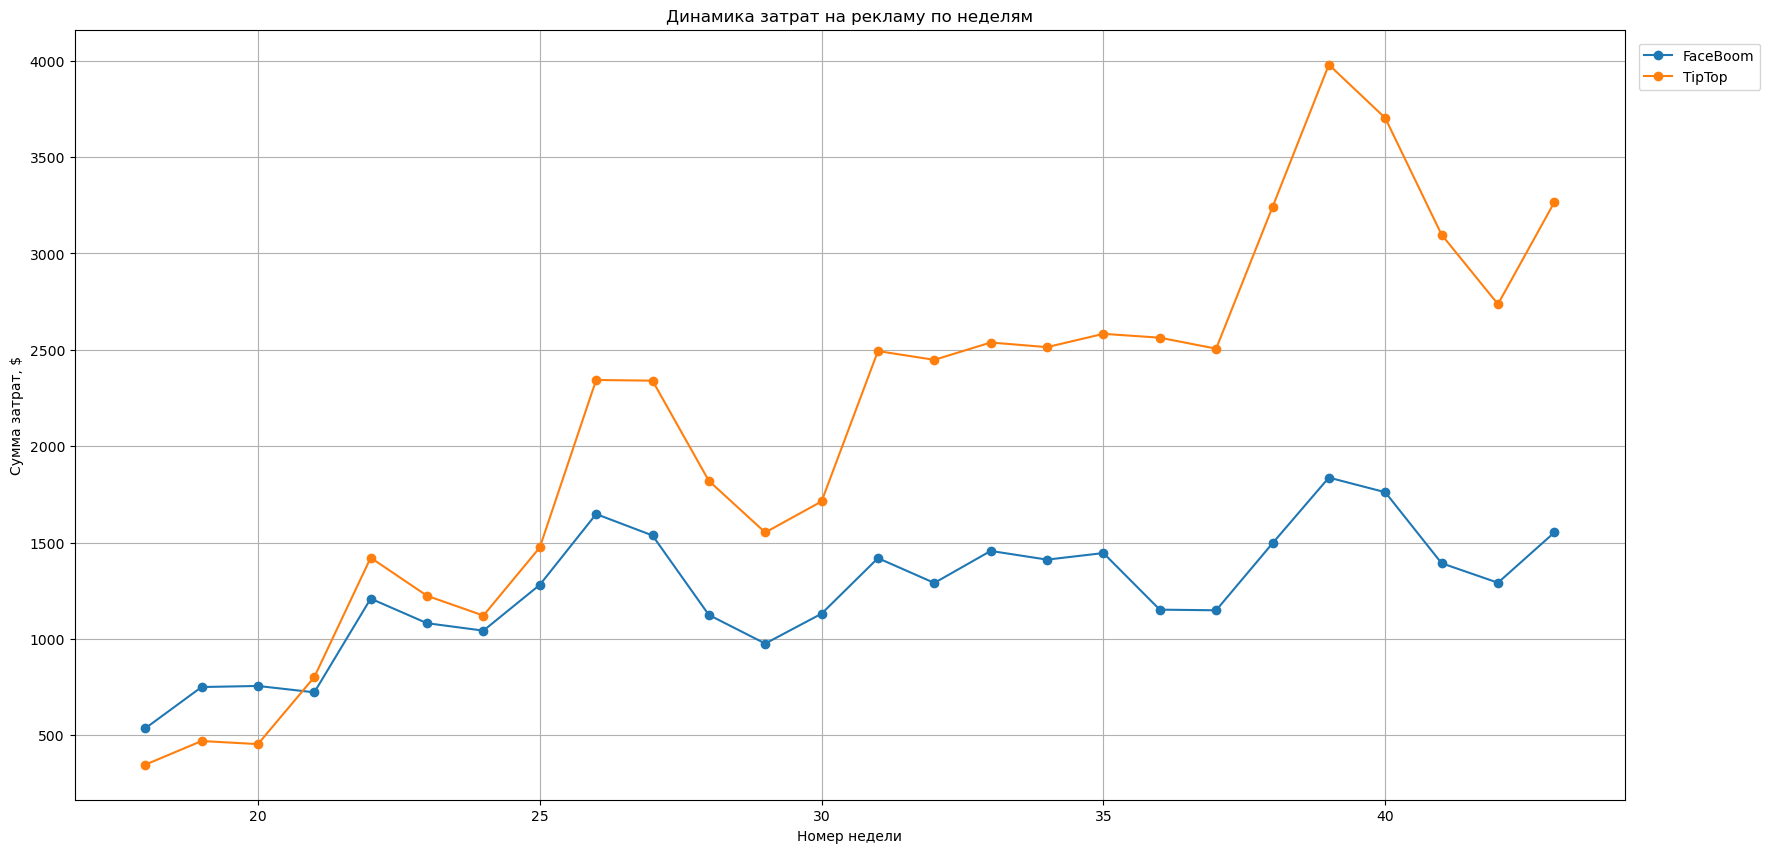

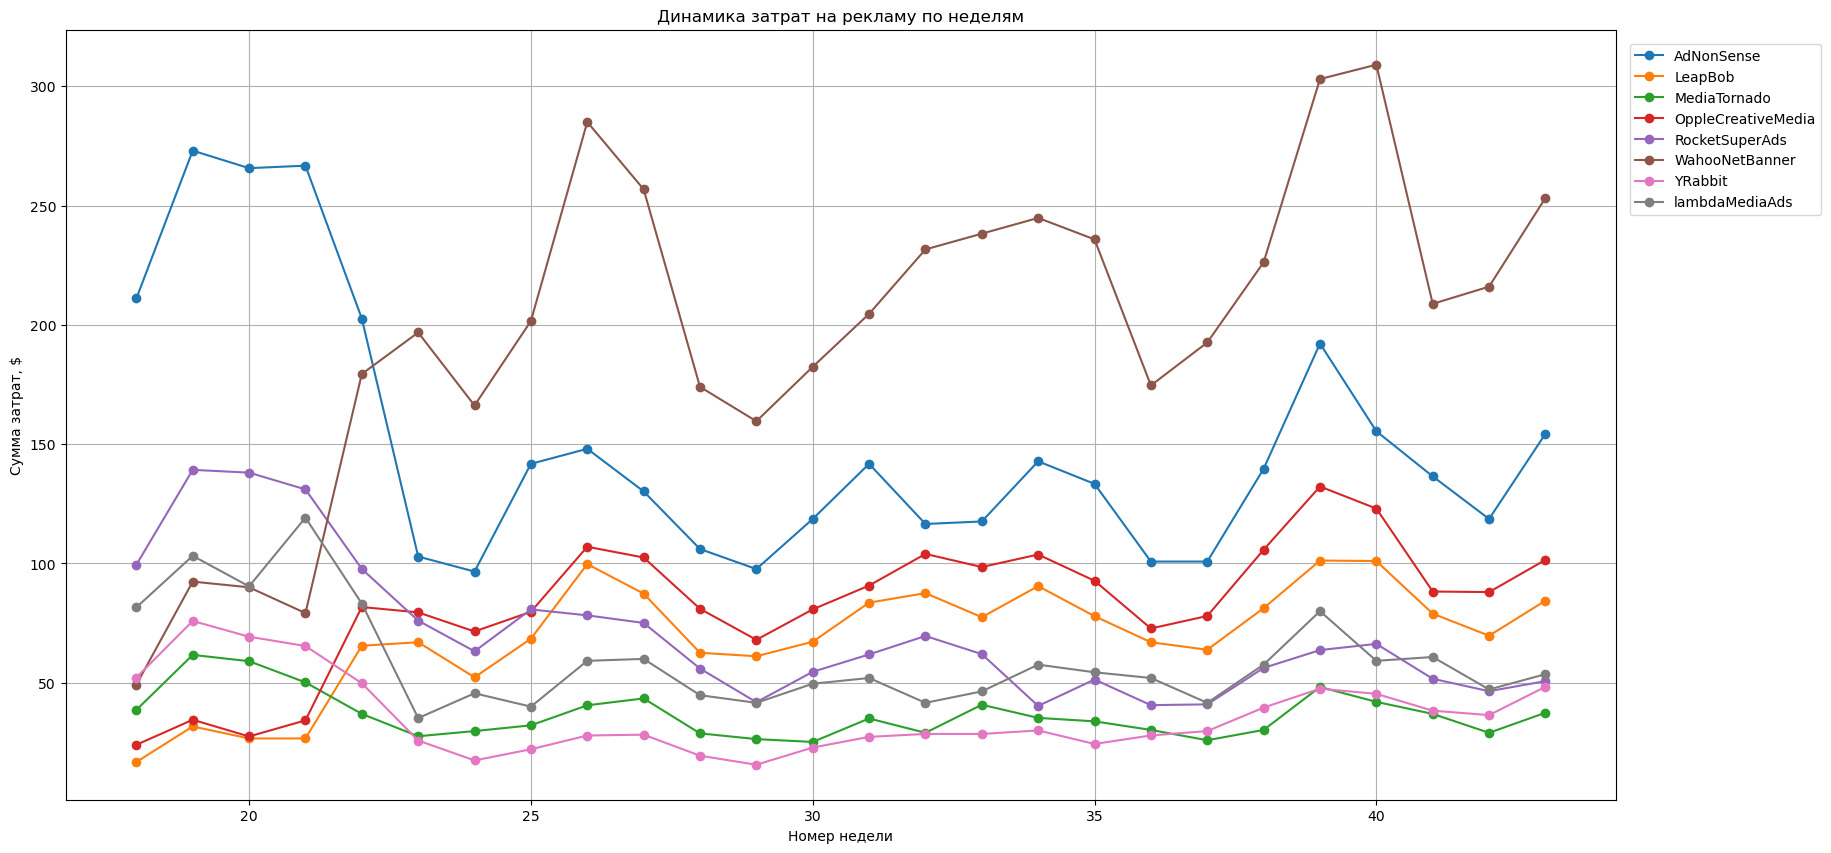

In [28]:
# строим график истории изменений CAC по каналам привлечения

week_cost[week_cost.index.isin(['TipTop', 'FaceBoom'])].T.plot(grid=True, figsize=(20, 10), style='o-')
plt.ylabel('Сумма затрат, $')
plt.xlabel('Номер недели')
plt.title('Динамика затрат на рекламу по неделям')
plt.legend(loc='upper left', borderaxespad= 1, bbox_to_anchor=(1, 1));

week_cost[~week_cost.index.isin(['TipTop', 'FaceBoom','organic'])].T.plot(grid=True, figsize=(20, 10), style='o-')
plt.ylabel('Сумма затрат, $')
plt.xlabel('Номер недели')
plt.title('Динамика затрат на рекламу по неделям')
plt.legend(loc='upper left', borderaxespad= 1, bbox_to_anchor=(1, 1));

Динамика расходов по всем рекламным платформам сходная. Несколько выбивается AdNonSense c большими расходами в начале рассматриваемого периода.

В целом виден постепенный рост расходов с небольшим провалом на 28-30 неделях и пиком на 38-40. 

In [29]:
month_cost=profiles.pivot_table (index='channel', columns='month', values='acquisition_cost', aggfunc='sum')


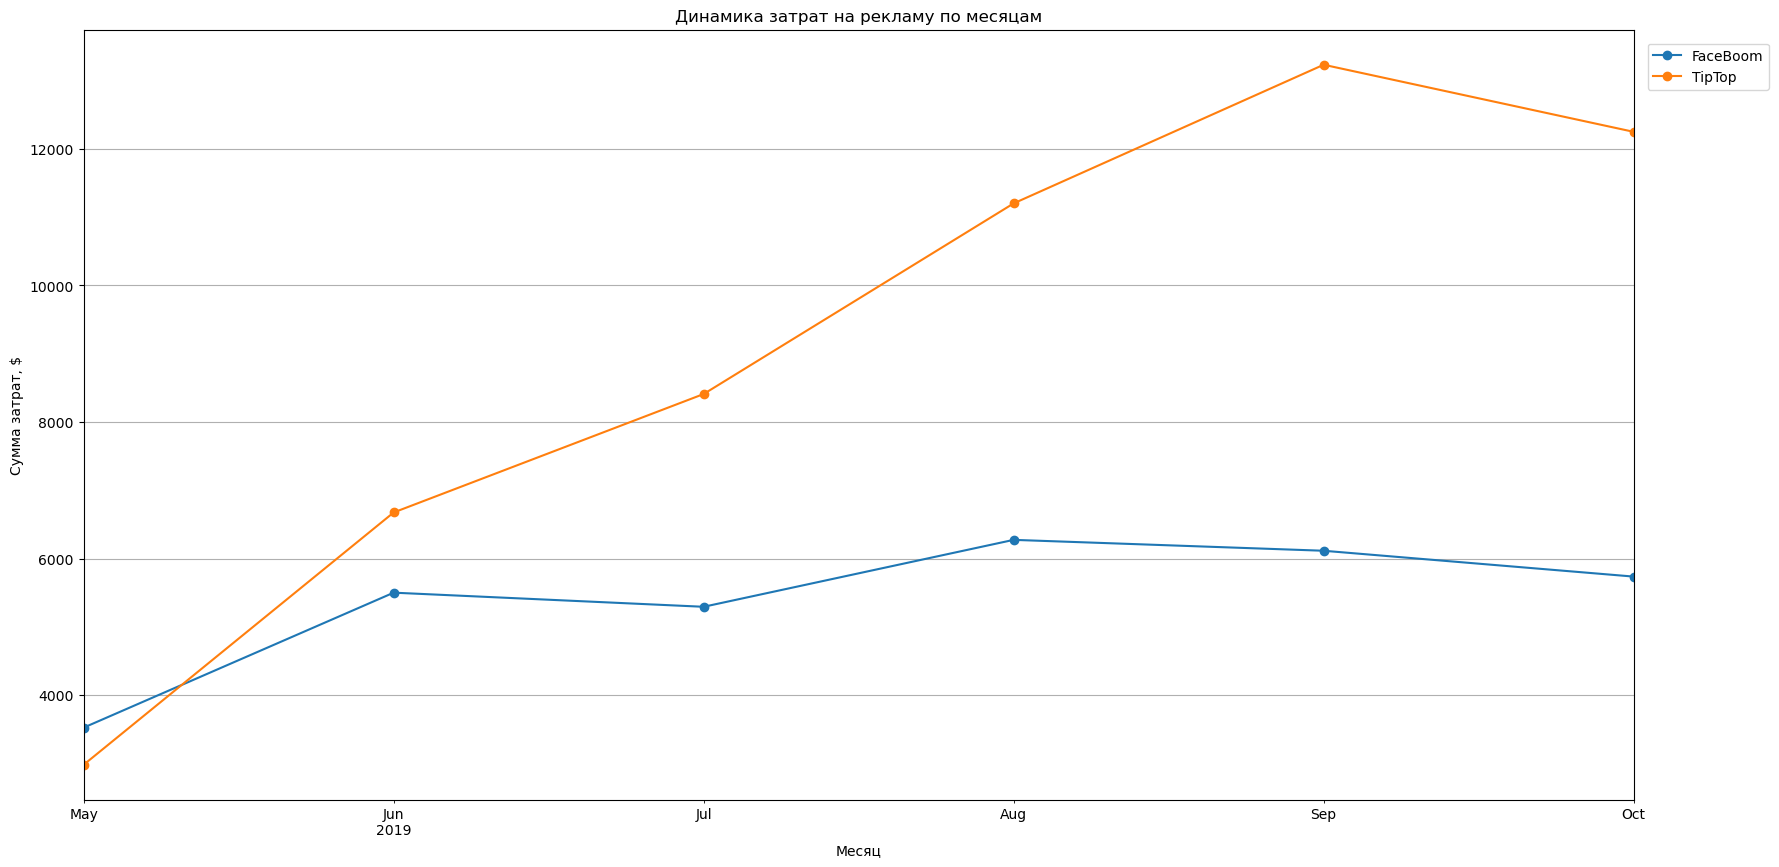

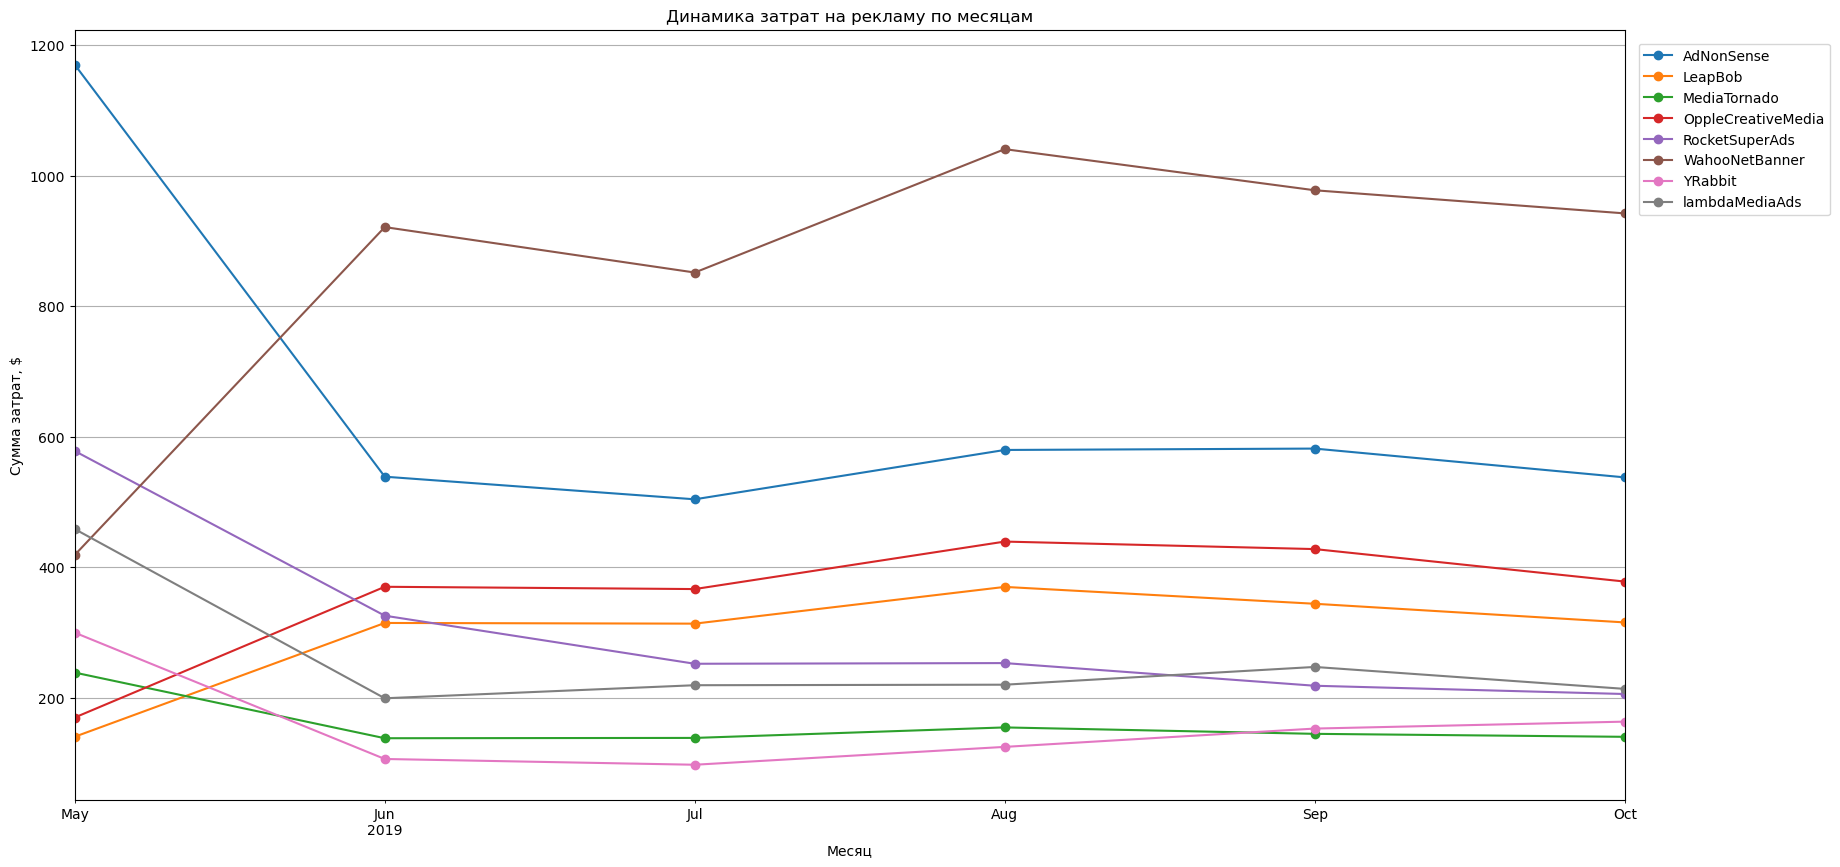

In [30]:
month_cost[month_cost.index.isin(['TipTop', 'FaceBoom'])].T.plot(grid=True, figsize=(20, 10), style='o-')
plt.ylabel('Сумма затрат, $')
plt.xlabel('Месяц')
plt.title('Динамика затрат на рекламу по месяцам')
plt.legend(loc='upper left', borderaxespad= 1, bbox_to_anchor=(1, 1));

month_cost[~month_cost.index.isin(['TipTop', 'FaceBoom', 'organic'])].T.plot(grid=True, figsize=(20, 10), style='o-')
plt.ylabel('Сумма затрат, $')
plt.xlabel('Месяц')
plt.title('Динамика затрат на рекламу по месяцам')
plt.legend(loc='upper left', borderaxespad= 1, bbox_to_anchor=(1, 1));

На графике с разрешением в месяц единтсвенный канал для которого остался виден пик в сентябре это Tip Top.

Для всех остальных видны изменнеия между маем и июнем, а в дальнейшем расходы остаются постоянными +-10%.


### Оцените окупаемость рекламы

Используя графики LTV, ROI и CAC, проанализируйте окупаемость рекламы. Считайте, что на календаре 1 ноября 2019 года, а в бизнес-плане заложено, что пользователи должны окупаться не позднее чем через две недели после привлечения. Необходимость включения в анализ органических пользователей определите самостоятельно.

- Проанализируйте окупаемость рекламы c помощью графиков LTV и ROI, а также графики динамики LTV, CAC и ROI.
- Проверьте конверсию пользователей и динамику её изменения. То же самое сделайте с удержанием пользователей. Постройте и изучите графики конверсии и удержания.
- Проанализируйте окупаемость рекламы с разбивкой по устройствам. Постройте графики LTV и ROI, а также графики динамики LTV, CAC и ROI.
- Проанализируйте окупаемость рекламы с разбивкой по странам. Постройте графики LTV и ROI, а также графики динамики LTV, CAC и ROI.
- Проанализируйте окупаемость рекламы с разбивкой по рекламным каналам. Постройте графики LTV и ROI, а также графики динамики LTV, CAC и ROI.
- Ответьте на такие вопросы:
    - Окупается ли реклама, направленная на привлечение пользователей в целом?
    - Какие устройства, страны и рекламные каналы могут оказывать негативное влияние на окупаемость рекламы?
    - Чем могут быть вызваны проблемы окупаемости?

Напишите вывод, опишите возможные причины обнаруженных проблем и промежуточные рекомендации для рекламного отдела.

In [31]:
#исключаем органических пользователей, так как они никак не связаны с рекламными расходами.
profiles_advertised = profiles.query('channel!="organic"')
observation_date = dt.datetime(2019, 11, 1).date()  # момент анализа
horizon_days = 14  # горизонт анализа 

#### Окупаемость рекламы

In [32]:
# считаем LTV и ROI
ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles_advertised, orders_info, observation_date, horizon_days
)


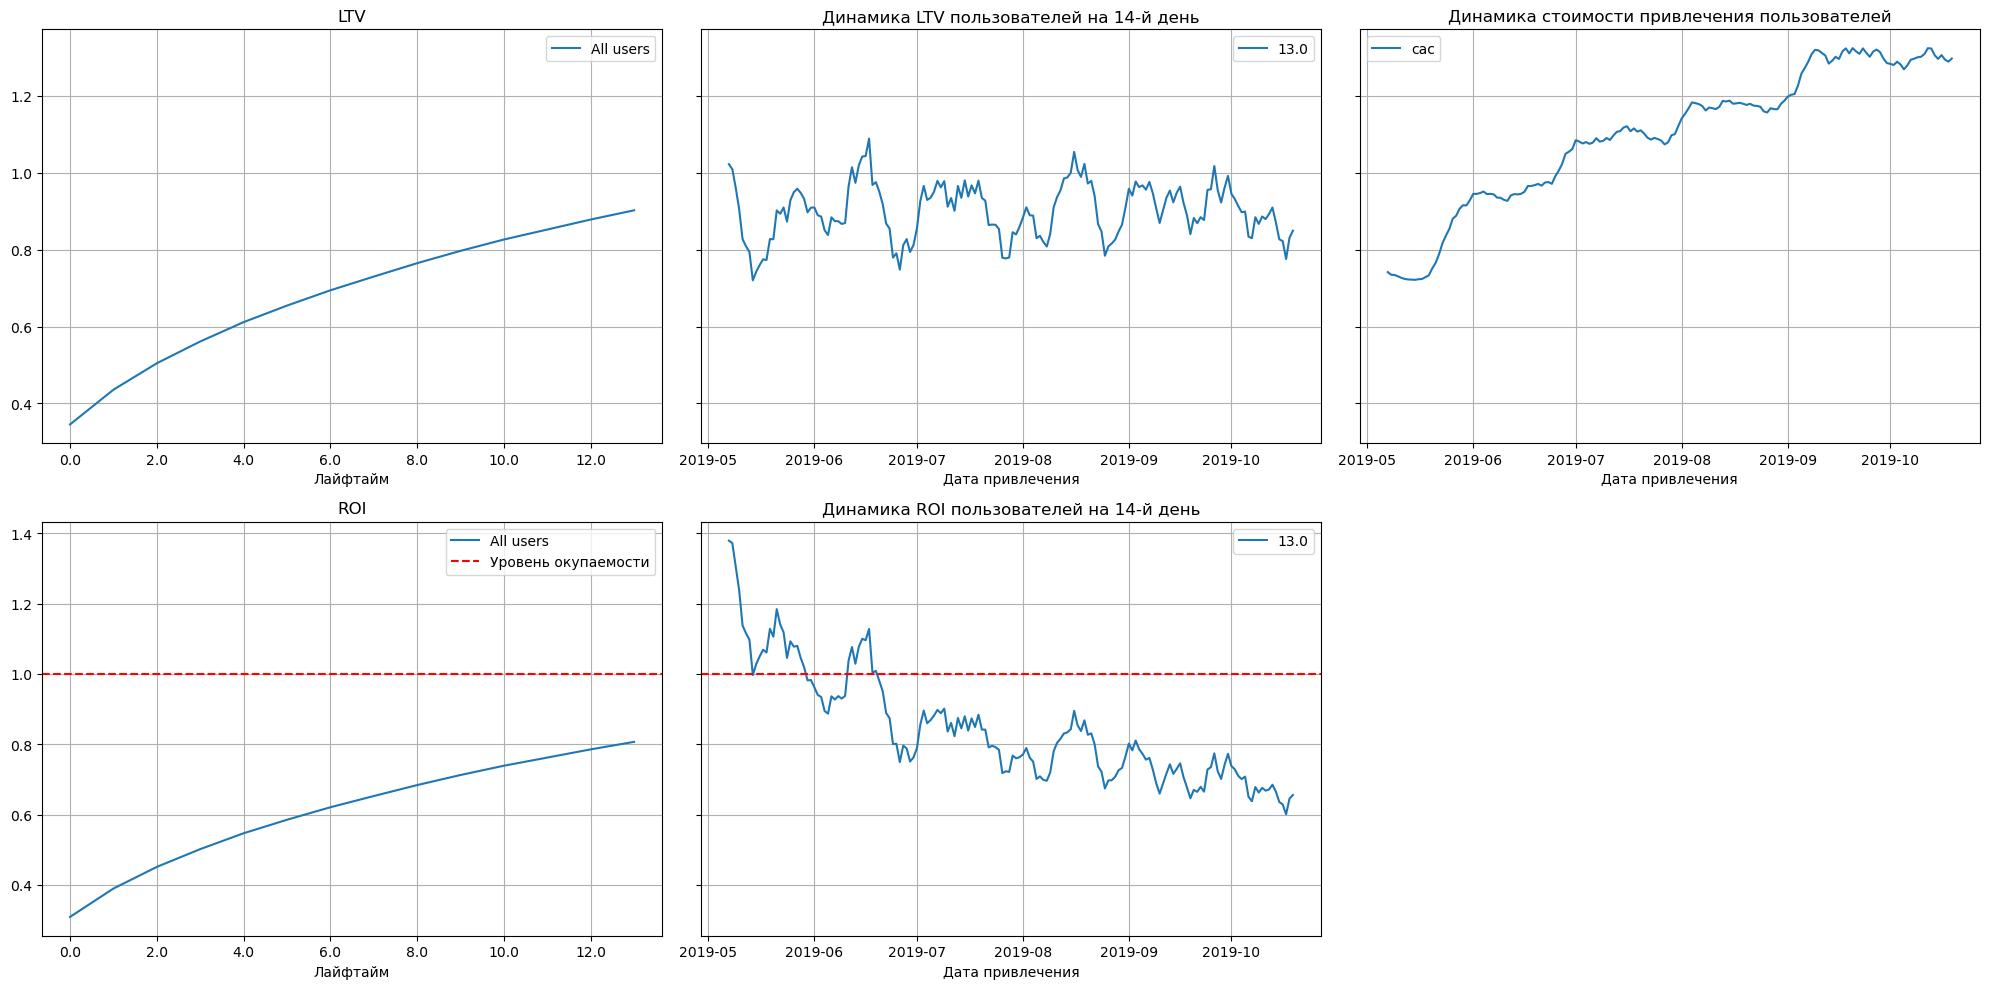

In [33]:
# строим графики
plot_ltv_roi(ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days) 

В целом LTV колеблется без явного тренда, CAC растёт, соотвественно ROI падает, к концу периода устойчиво уйдя ниже уровня окупаемости.

#### Конверсия и удержание

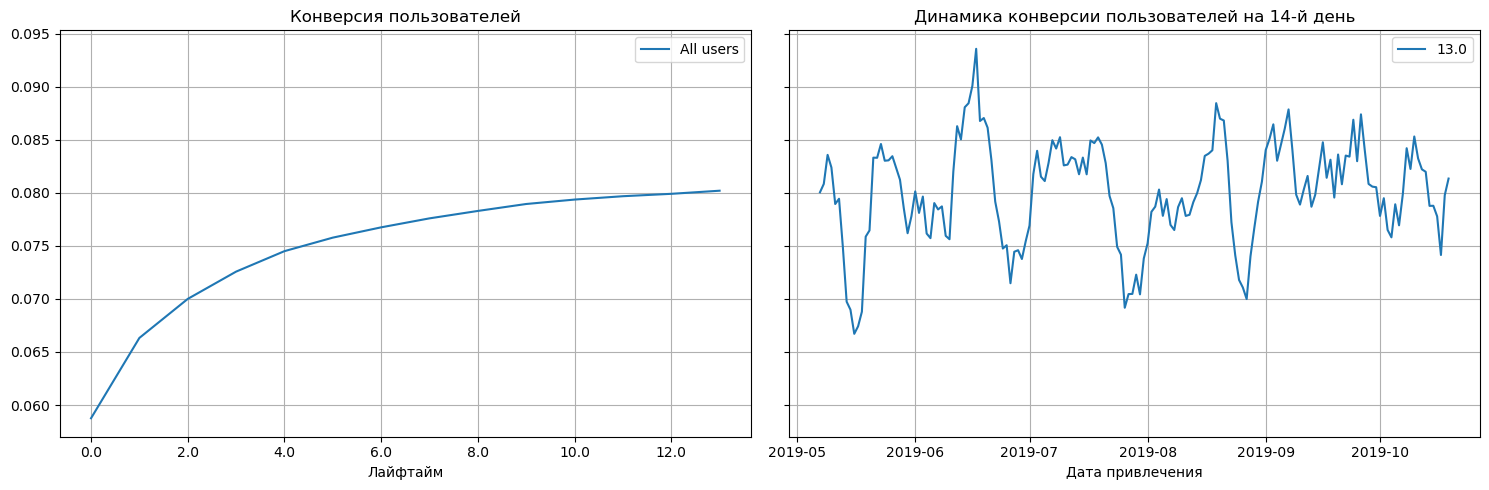

In [34]:
conversion_raw, conversion_grouped, conversion_history = get_conversion(
    profiles_advertised, orders_info, observation_date, horizon_days
)

plot_conversion(conversion_grouped, conversion_history, horizon_days)

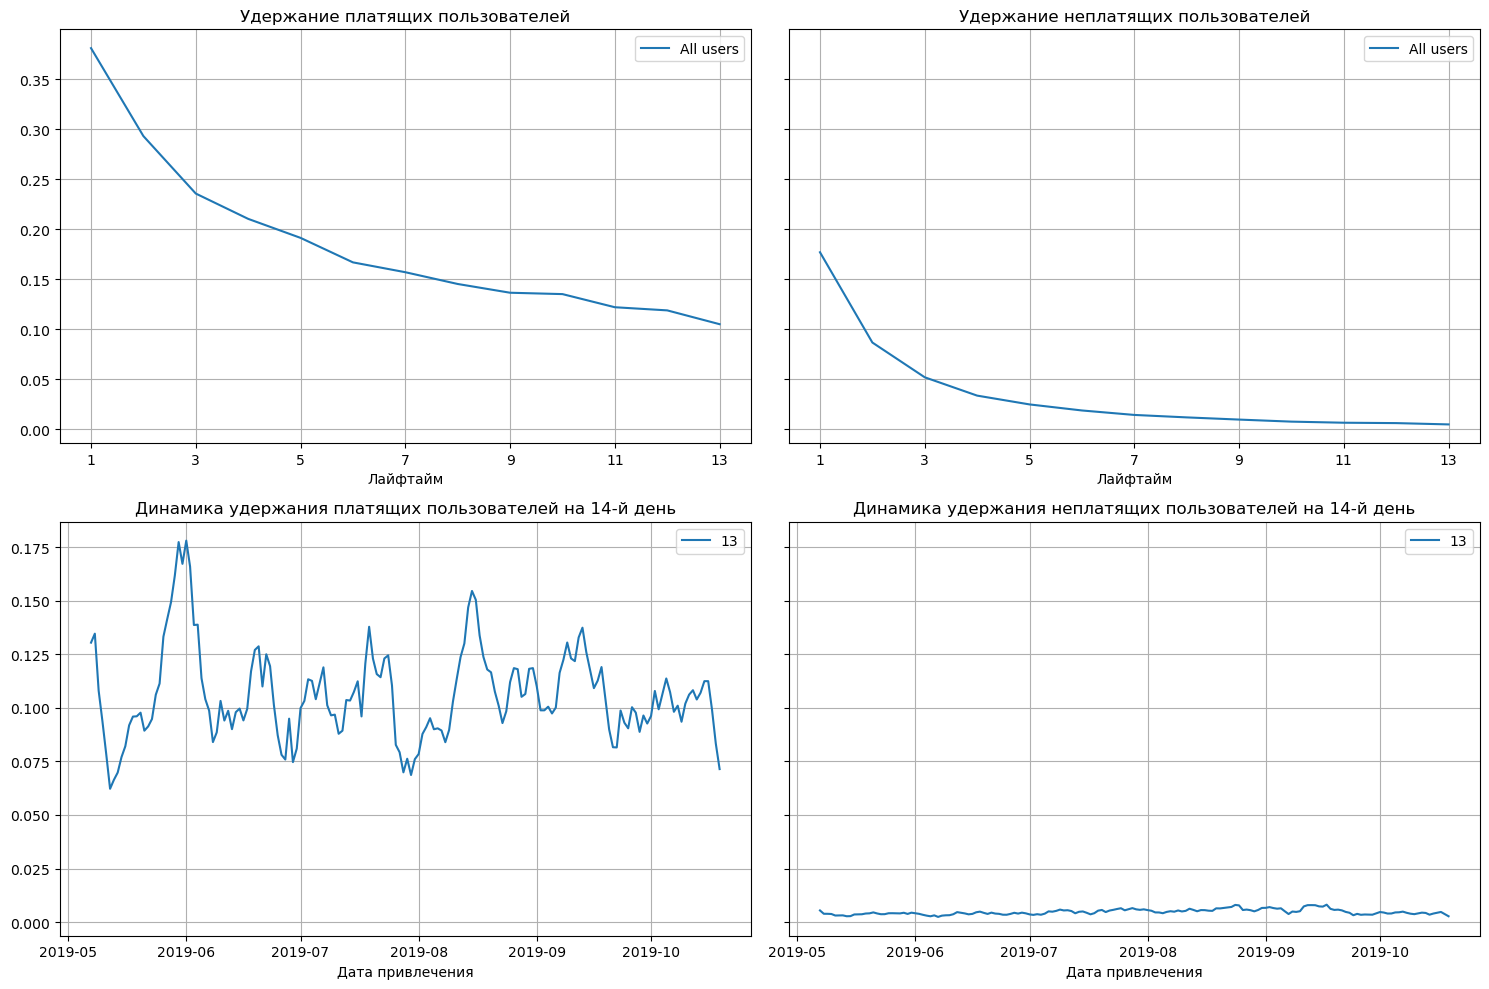

In [35]:
retention_raw, retention_grouped, retention_history = get_retention(
    profiles_advertised, visits_info, observation_date, horizon_days
)

plot_retention(retention_grouped, retention_history, horizon_days) 

Конверсия колеблется вокруг 8%, двухнедельное удержание колеблется вокруг 10% для платящих пользователей и пренебрежимо мало для неплатящих.

#### Окупаемость рекламы по устройствам

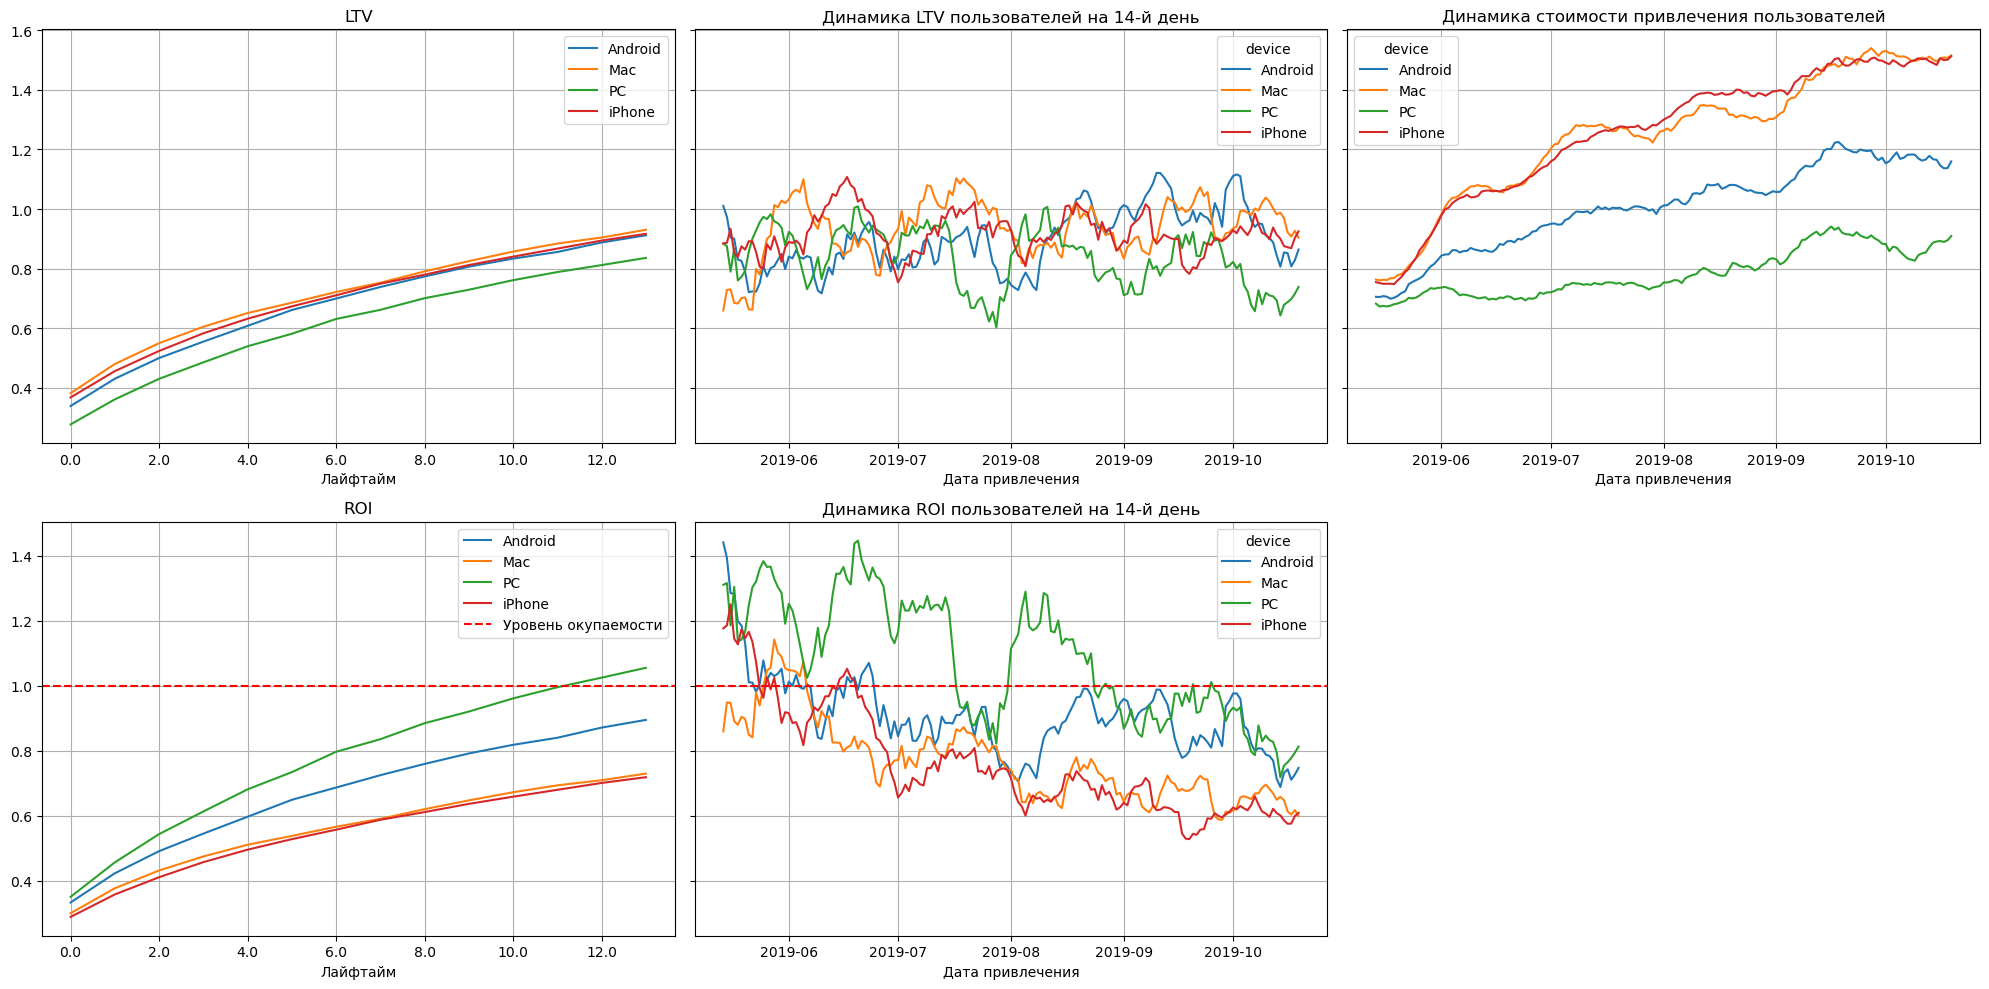

In [36]:
dimensions = ['device']

ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles_advertised, orders_info, observation_date, horizon_days, dimensions=dimensions
)

plot_ltv_roi(
    ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days, window=14
) 

Тренды для всех устройств схожи друг с другом и общим трендом рассмотренным в предыдущем блоке. 

ROI для пользователей PC чуть выше единицы, но это, скорее всего, связано с тем что их меньше в проблемных регионах и/или каналах распространения, а не с особенностями платформы.

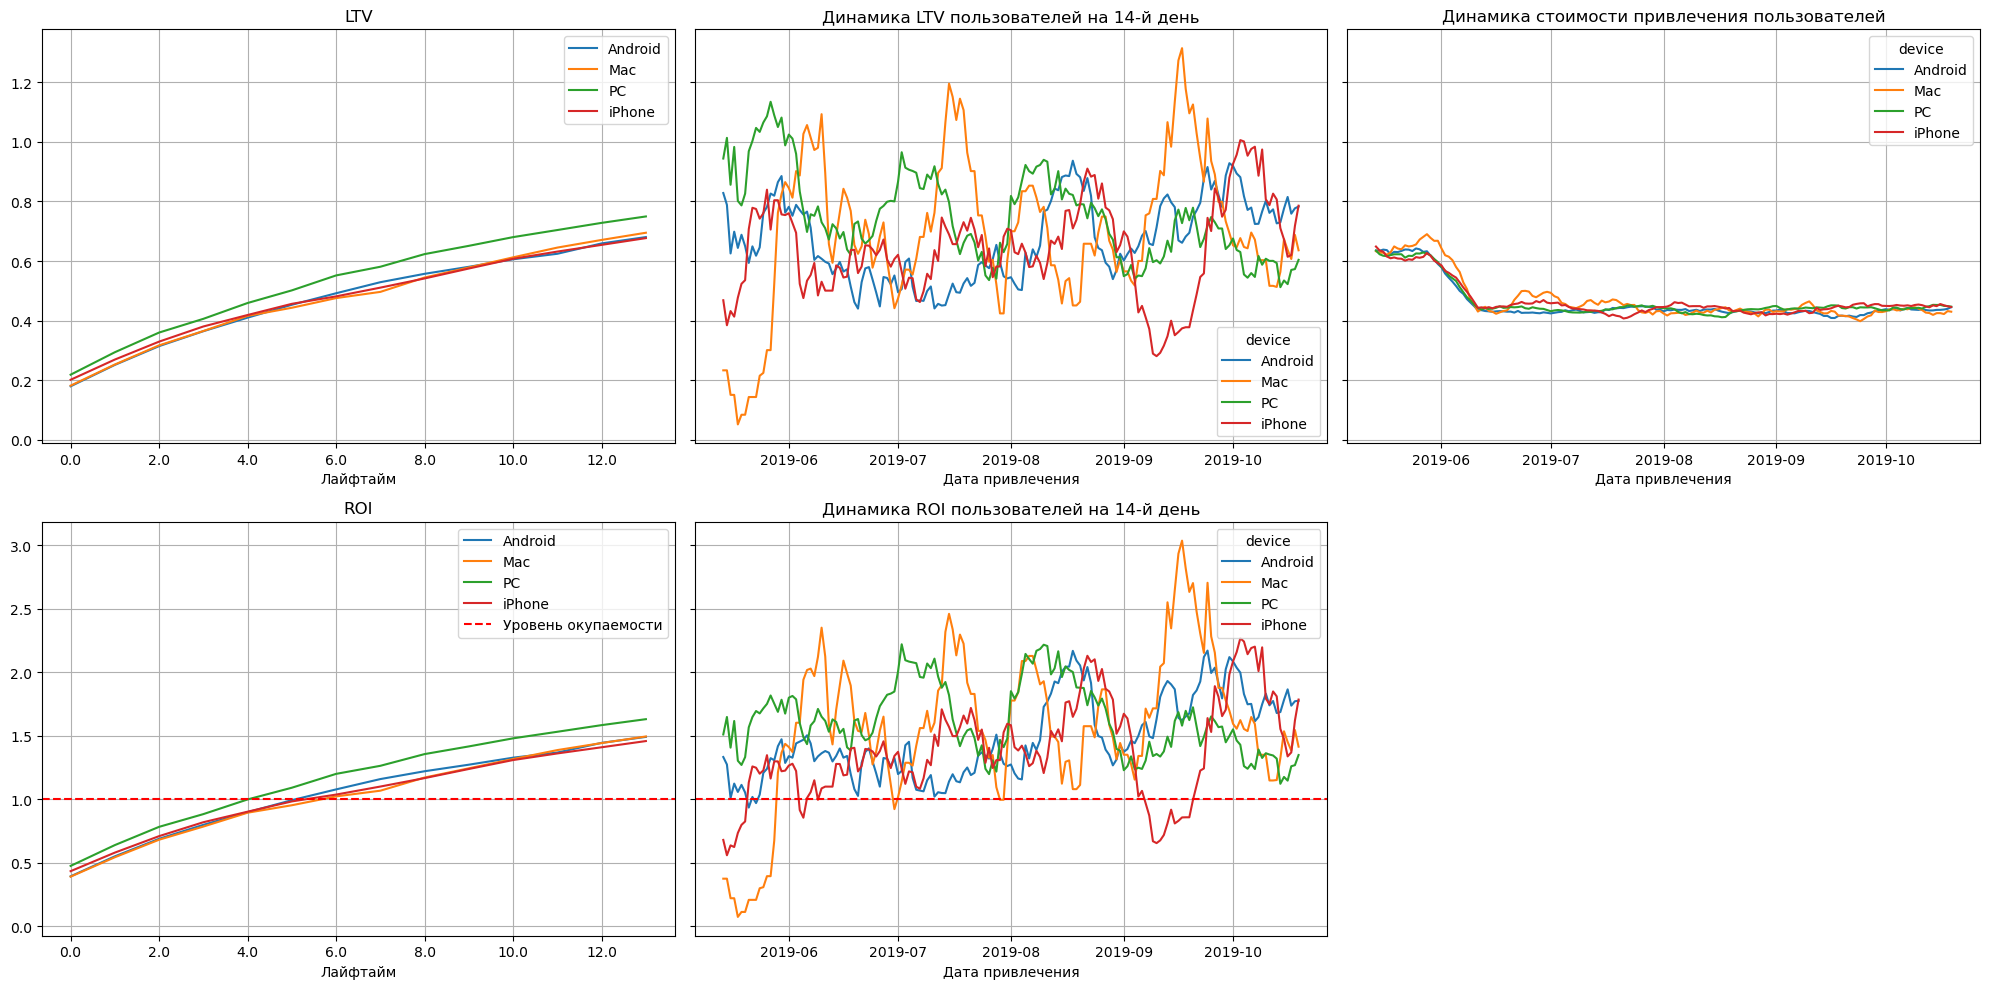

In [37]:
profiles_advertised_EU = profiles_advertised.query('region!="United States"')#.query('(channel!="TipTop") and (channel!="FaceBoom")')
dimensions = ['device']

ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles_advertised_EU, orders_info, observation_date, horizon_days, dimensions=dimensions
)

plot_ltv_roi(
    ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days, window=14
)

#### Окупаемость рекламы по каналам

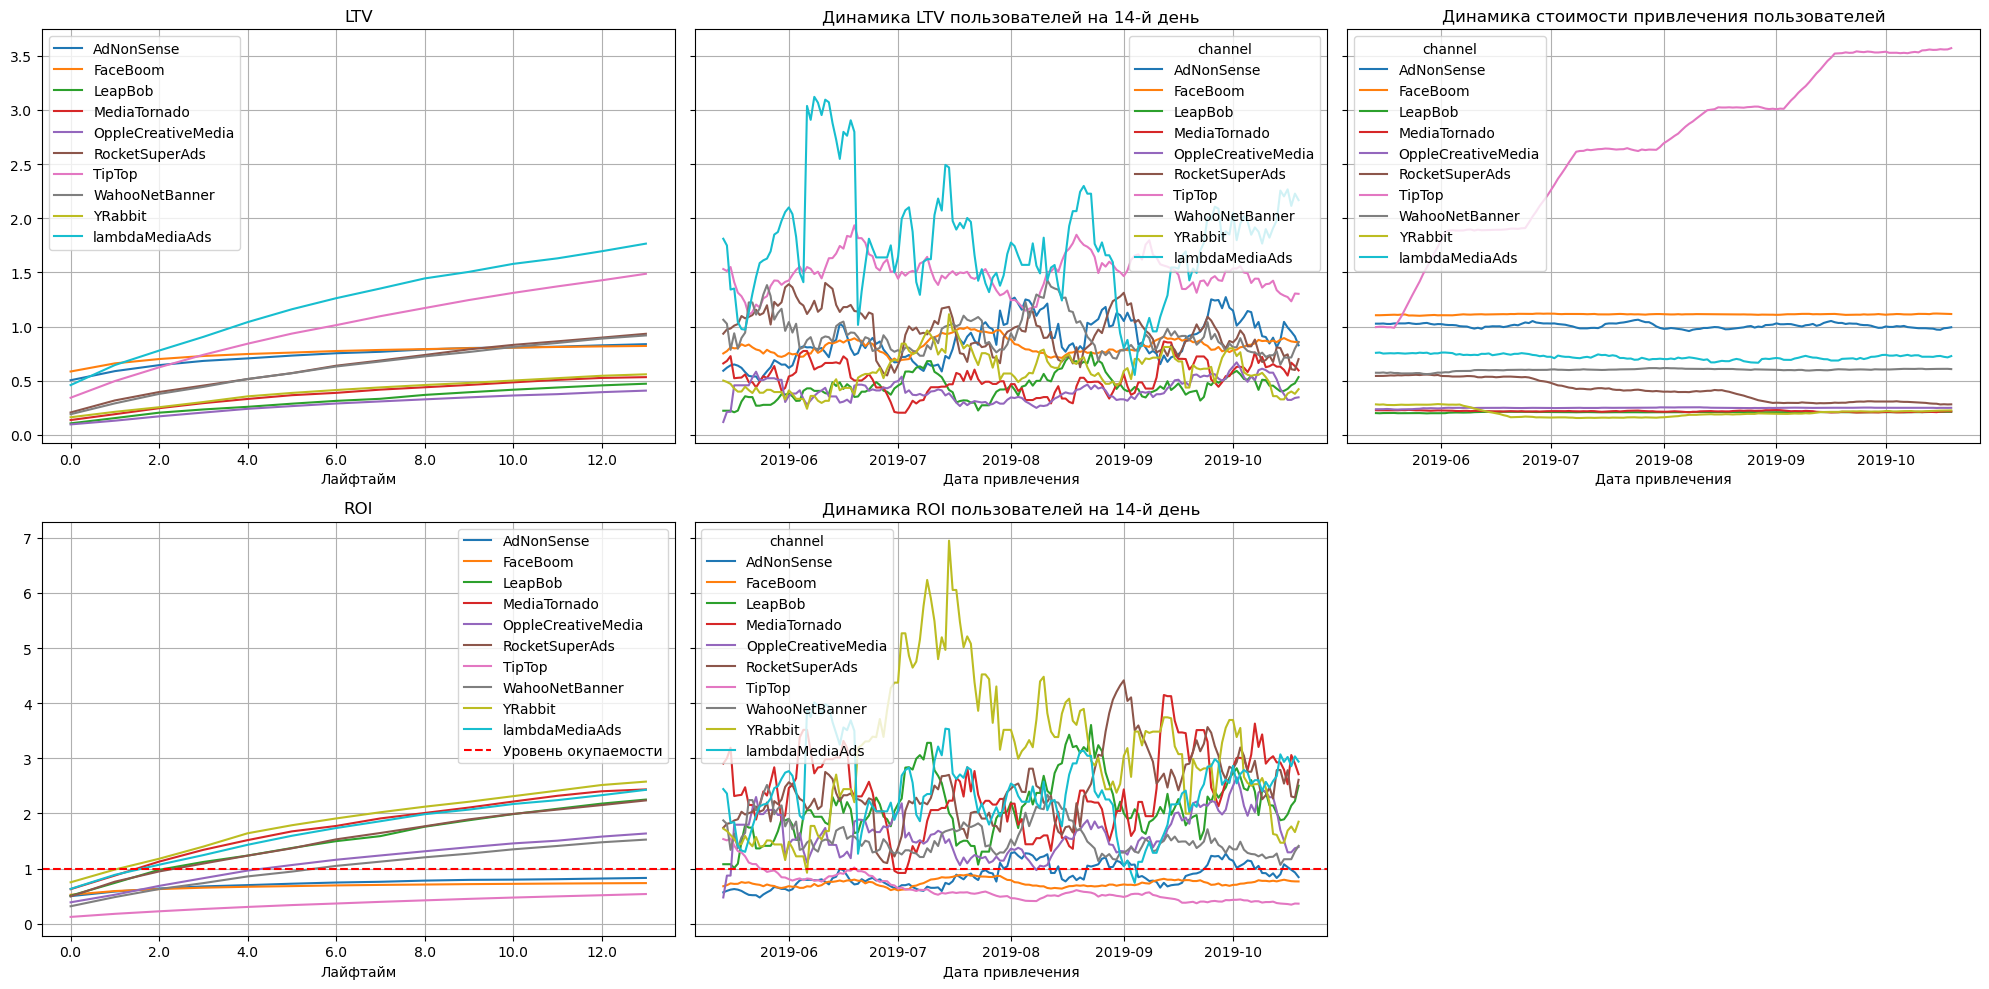

In [38]:

dimensions = ['channel']

ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles_advertised, orders_info, observation_date, horizon_days, dimensions=dimensions
)

plot_ltv_roi(
    ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days, window=14
)

Виден серьёзный рост CAC для TipTop, для всех остальных каналов он остаётся на одном уровне.

3 канала находятся ниже уровня окупаемости, в том числе два наиболее крупных(как по вложениям так и по количеству привлеченных пользователей).

#### Окупаемость рекламы по странам

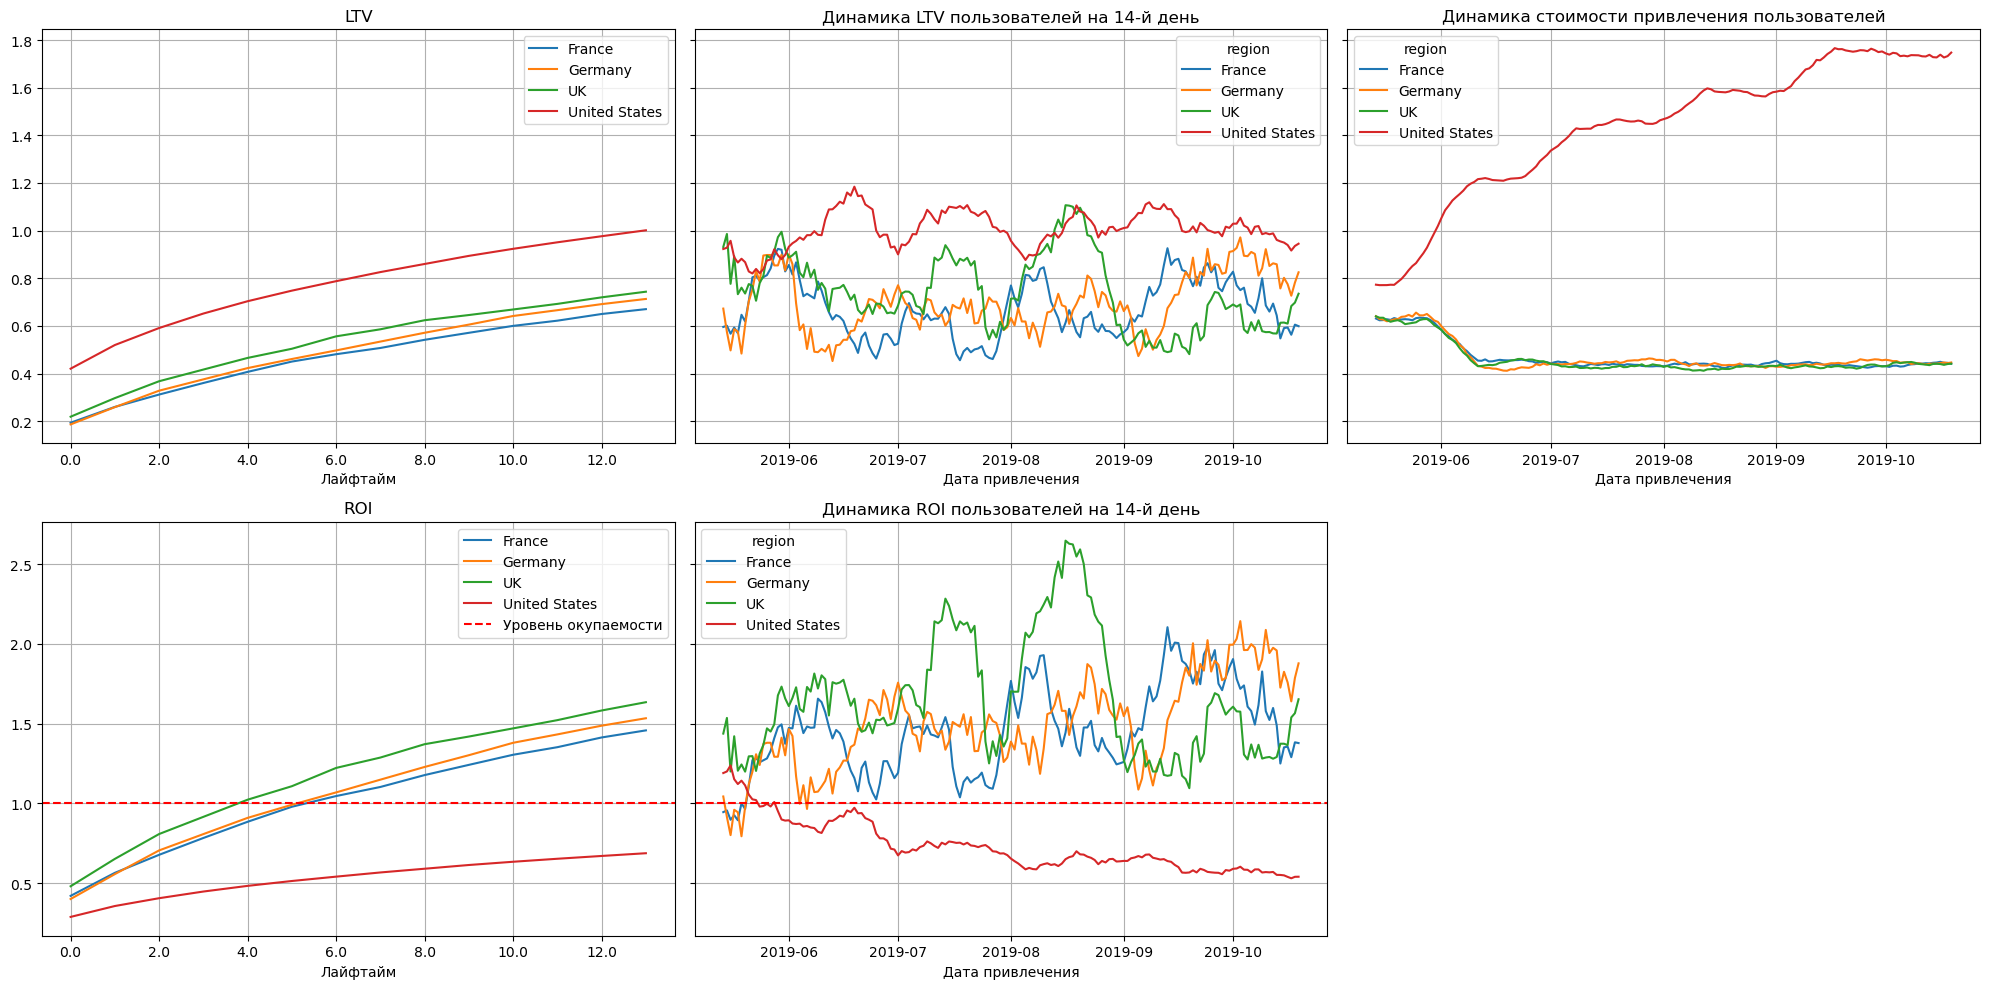

In [39]:

dimensions = ['region']

ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles_advertised, orders_info, observation_date, horizon_days, dimensions=dimensions
)

plot_ltv_roi(
    ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days, window=14
)

- Европейский рынок можно рассматривать в совокупности, так как в нём практически не видно различий по обеим метрикам.
- Реклама на европейском рынке окупается
- Реклама на американском рынке сильно убыточна

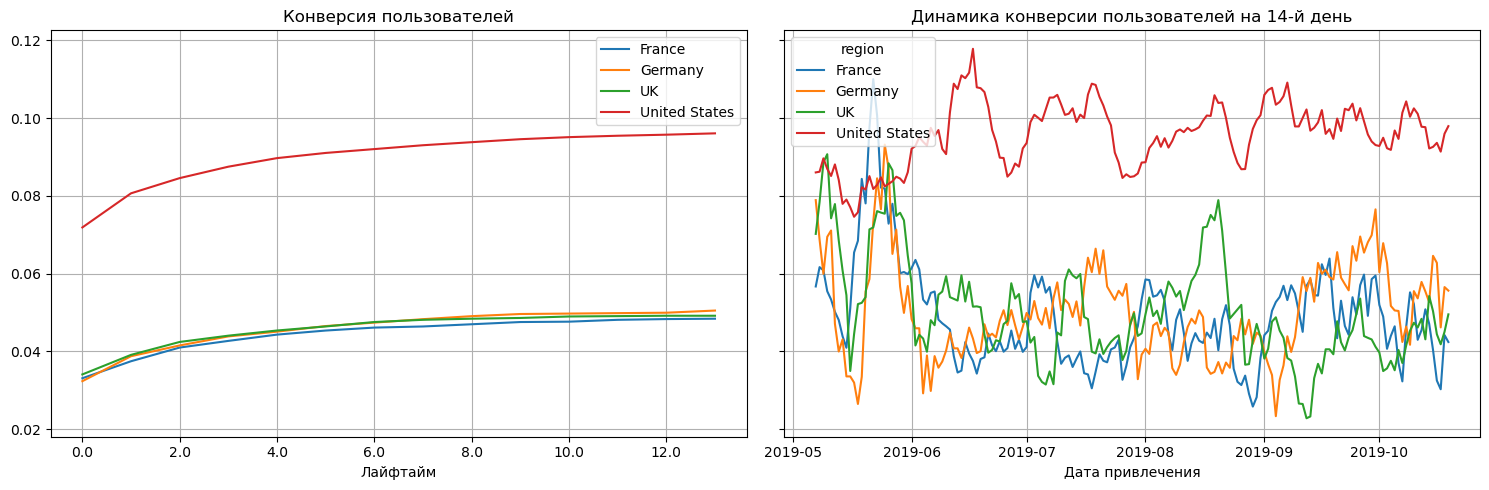

In [40]:
conversion_raw, conversion_grouped, conversion_history = get_conversion(
    profiles_advertised, orders_info, observation_date, horizon_days, dimensions=dimensions
)

plot_conversion(conversion_grouped, conversion_history, horizon_days) 

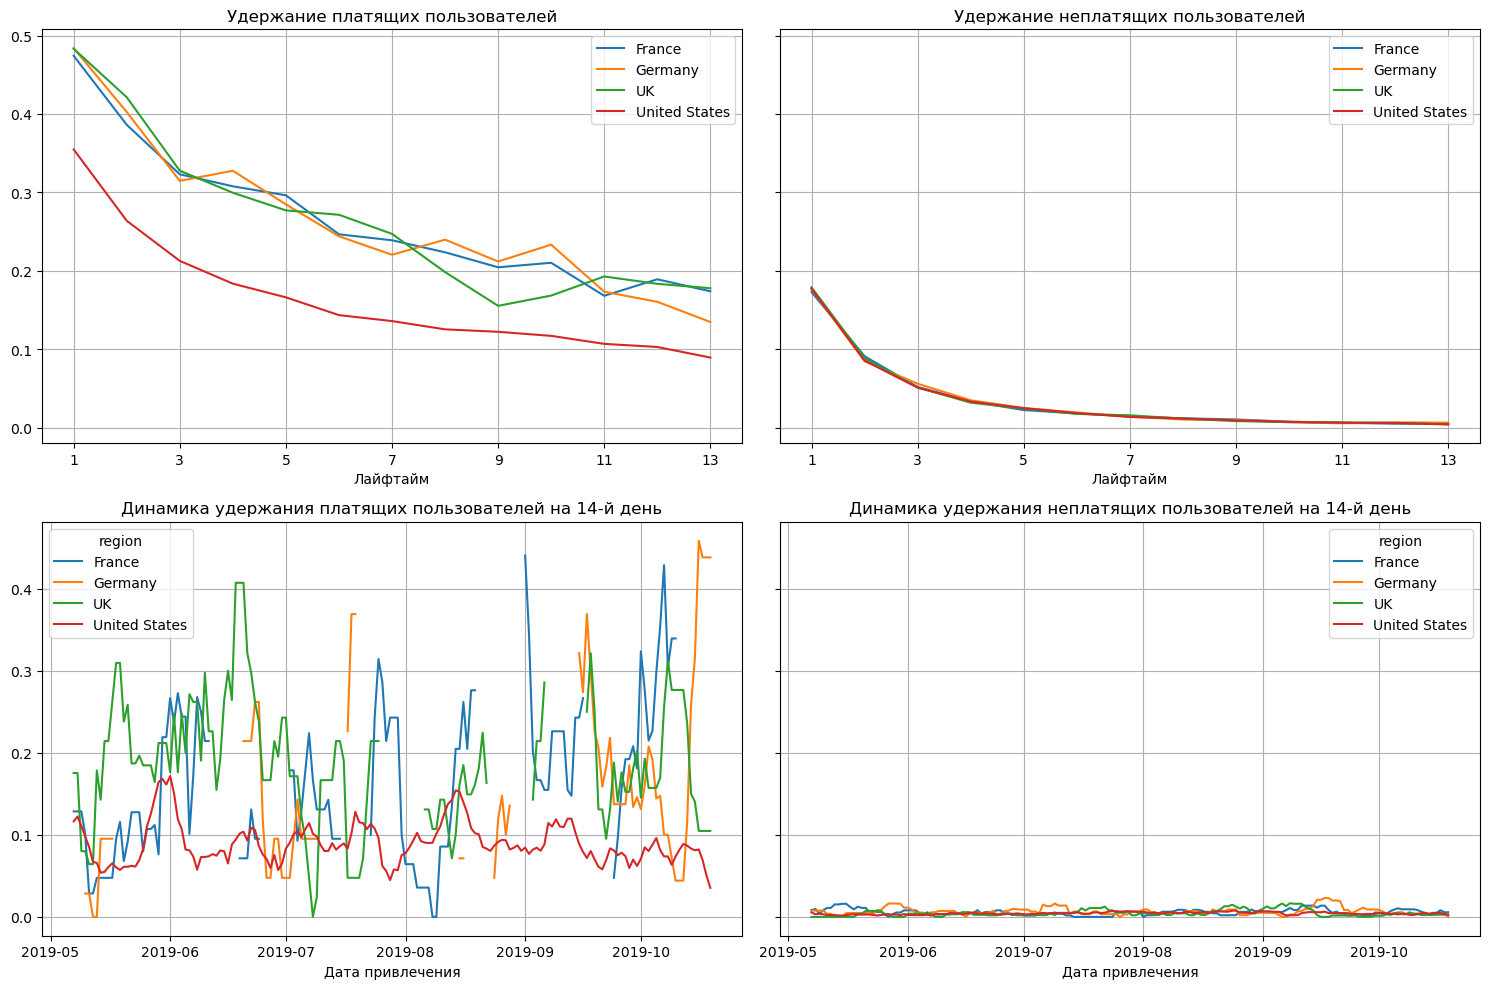

In [41]:
retention_raw, retention_grouped, retention_history = get_retention(
    profiles_advertised, visits_info, observation_date, horizon_days, dimensions=dimensions
)

plot_retention(retention_grouped, retention_history, horizon_days) 

 - Так же видно бинарное деление на Европу и Америку, но только для платящих пользователей
 - Удержание американских пользователей, с одной стороны, заметно ниже, с другой - испытывает меньше изменений во времени.
 - Конверсия американских пользователей, напротив того, почти вдвое выше чем европейских.

#### Промежуточные выводы по окупаемости

Видны две проблемы:
- Цена привлечения через TipTop постоянно росла, при этом их LTV оставался неизменным
- Несмотря на самый высокий LTV пользователи из США не окупаются

По всей видимости рекламу в TipTop надо исключать полностью. С США так сделать нельзя, так как это больше половины всех клиентов

##### Окупаемость рекламы за исключением неэффективного канала

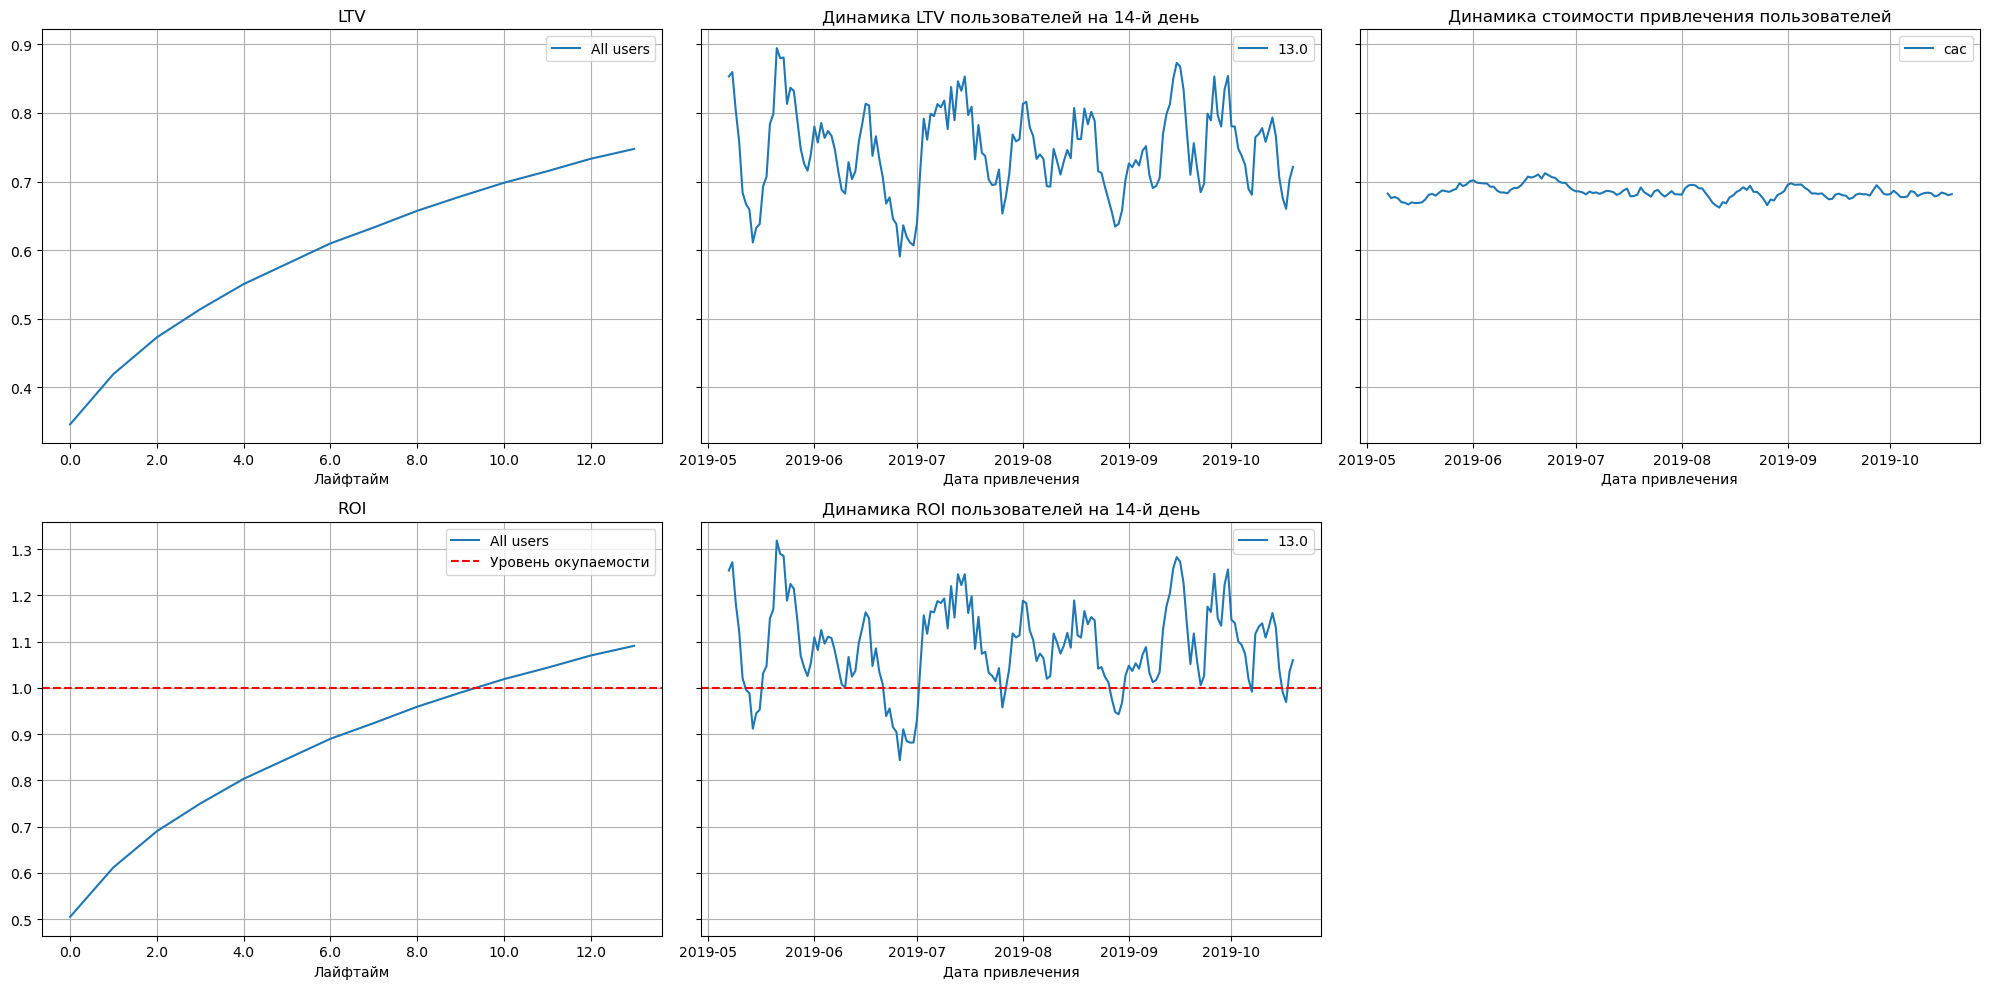

In [42]:
profiles_good_advertised = profiles_advertised.query('channel!="TipTop"')
# считаем LTV и ROI
ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles_good_advertised, orders_info, observation_date, horizon_days
)
# строим графики
plot_ltv_roi(ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days) 

Уже вышли на уровень окупаемости. Посмотрим ещё раз на страны:

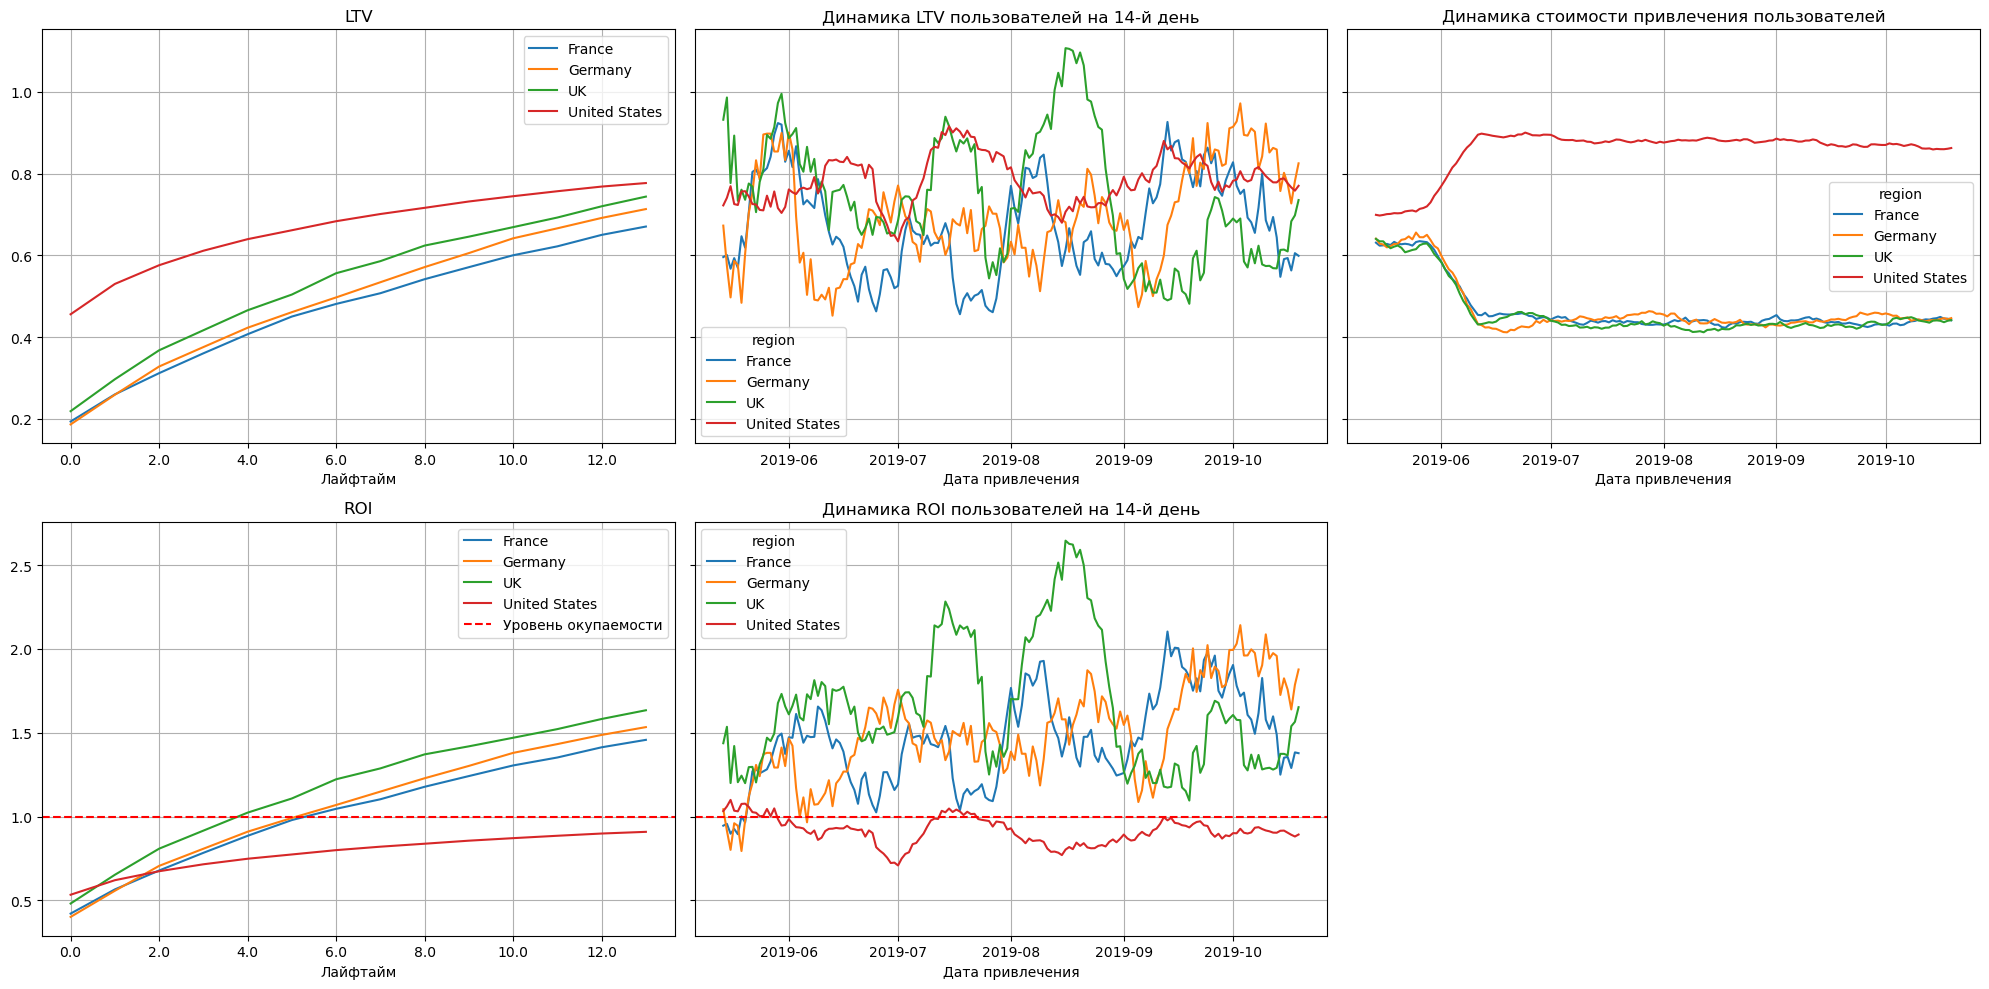

In [43]:
dimensions = ['region']

ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles_good_advertised, orders_info, observation_date, horizon_days, dimensions=dimensions
)

plot_ltv_roi(
    ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days, window=14
)

Америка всё ещё в минусе, посмотрим на неё отдельно

##### Окупаемость рекламы в США по каналам

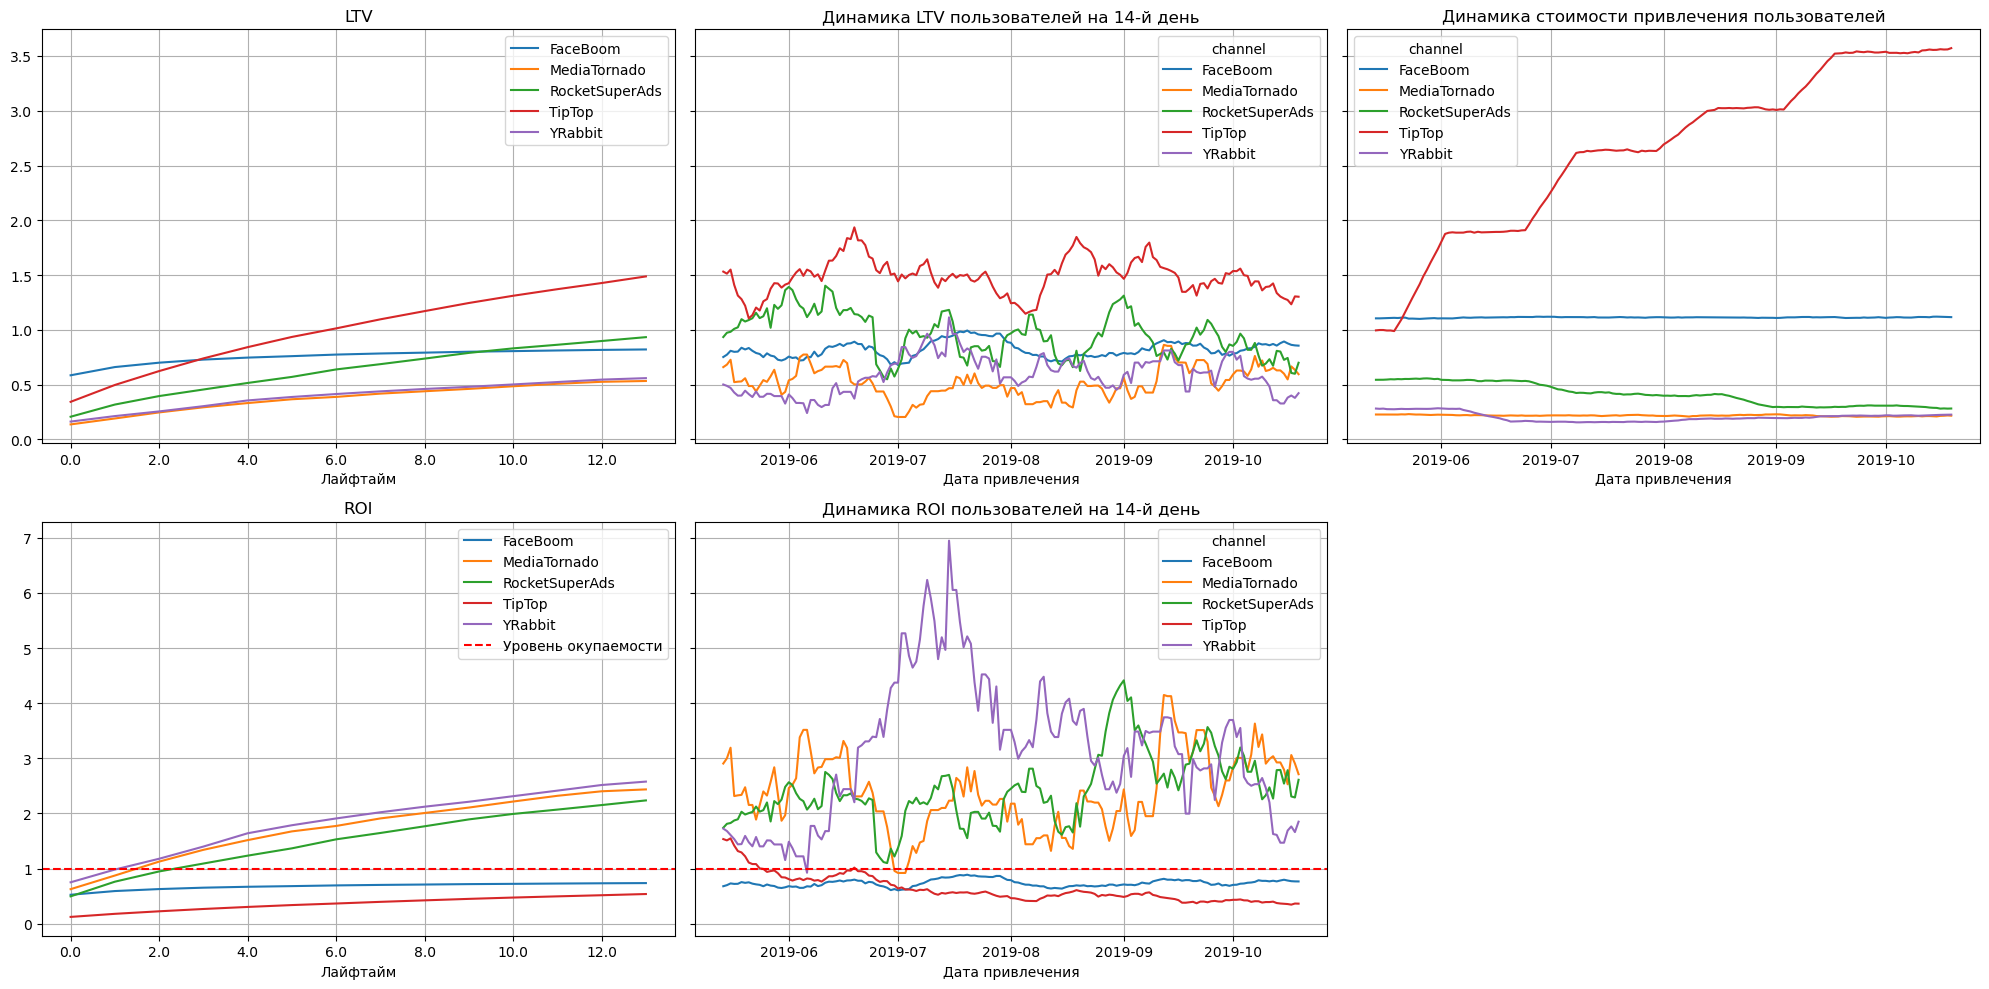

,mean,sum,count
channel,,,
FaceBoom,0.122049,3557,29144
TipTop,0.096007,1878,19561
RocketSuperAds,0.079137,352,4448
MediaTornado,0.035747,156,4364
YRabbit,0.038265,165,4312


In [44]:
profiles_advertised_US = profiles_advertised.query('region=="United States"')
dimensions = ['channel']

ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles_advertised_US, orders_info, observation_date, horizon_days, dimensions=dimensions
)

plot_ltv_roi(
    ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days, window=14
)

profiles_by_channel_US = pivot_by(profiles_advertised_US,'channel', {'user_id':['count'], 'payer_count':['mean', 'sum']})
profiles_by_channel_US = profiles_by_channel_US.sort_values(by='count',ascending=False)

display(profiles_by_channel_US)

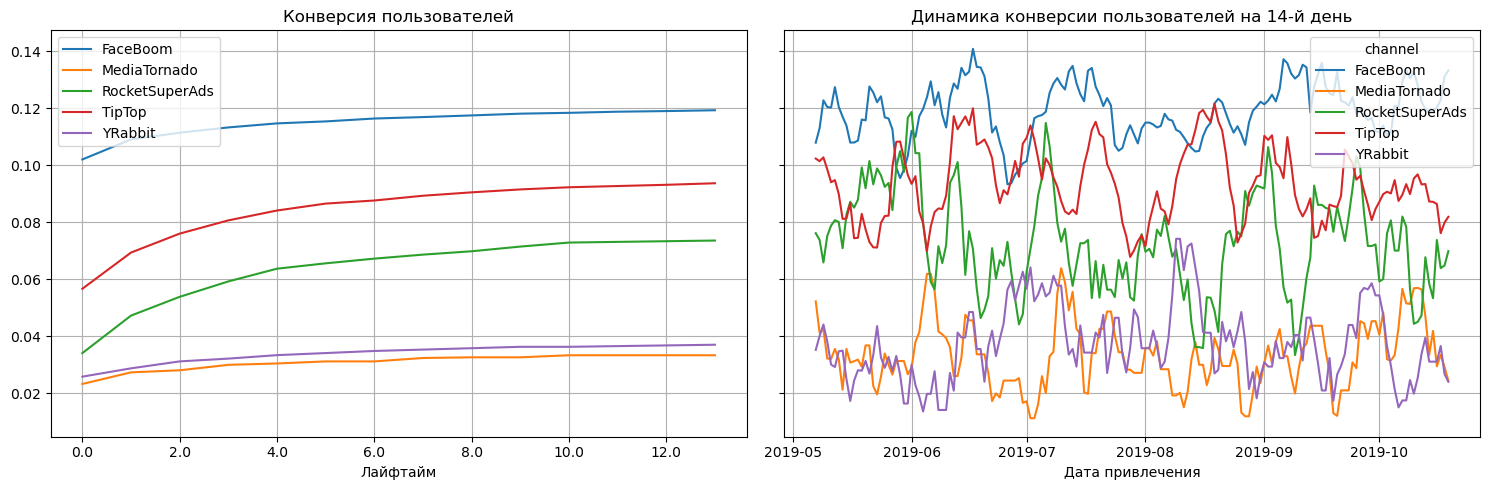

In [45]:
conversion_raw, conversion_grouped, conversion_history = get_conversion(
    profiles_advertised_US, orders_info, observation_date, horizon_days, ['channel']
)

plot_conversion(conversion_grouped, conversion_history, horizon_days)

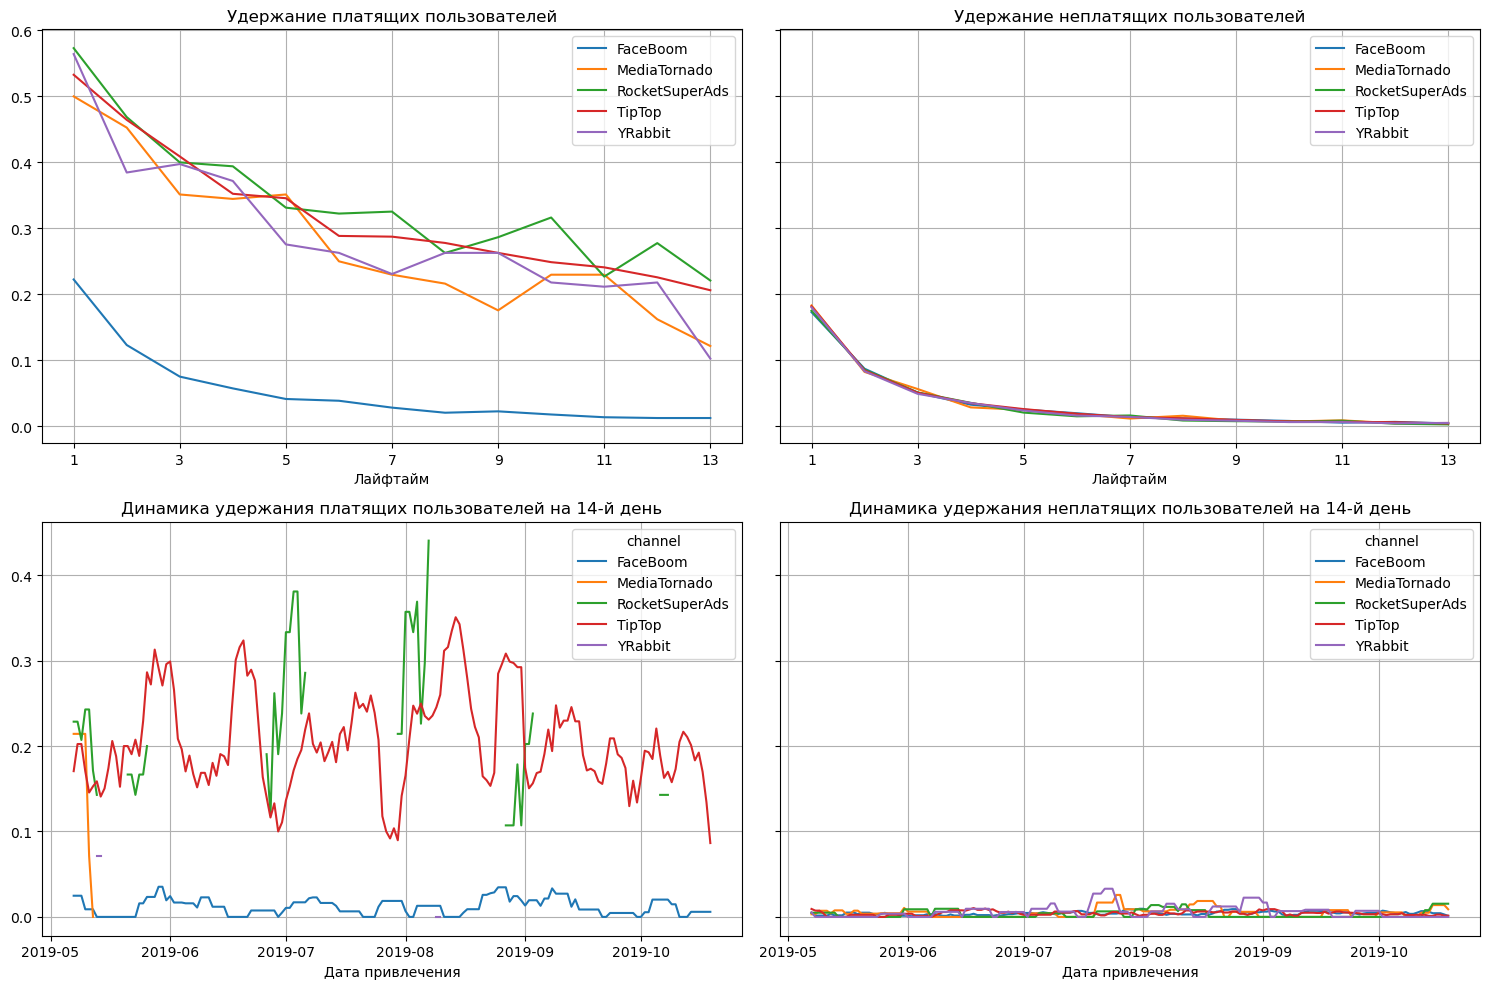

In [46]:
retention_raw, retention_grouped, retention_history = get_retention(
    profiles_advertised_US, visits_info, observation_date, horizon_days, ['channel']
)

plot_retention(retention_grouped, retention_history, horizon_days) 

Явно выделяется FaceBoom крайне низким удержанием, при этом у него максимальная конверсия. На всякий случай посмотрим на распределение по устройствам

##### Окупаемость рекламы на FaceBoom в США

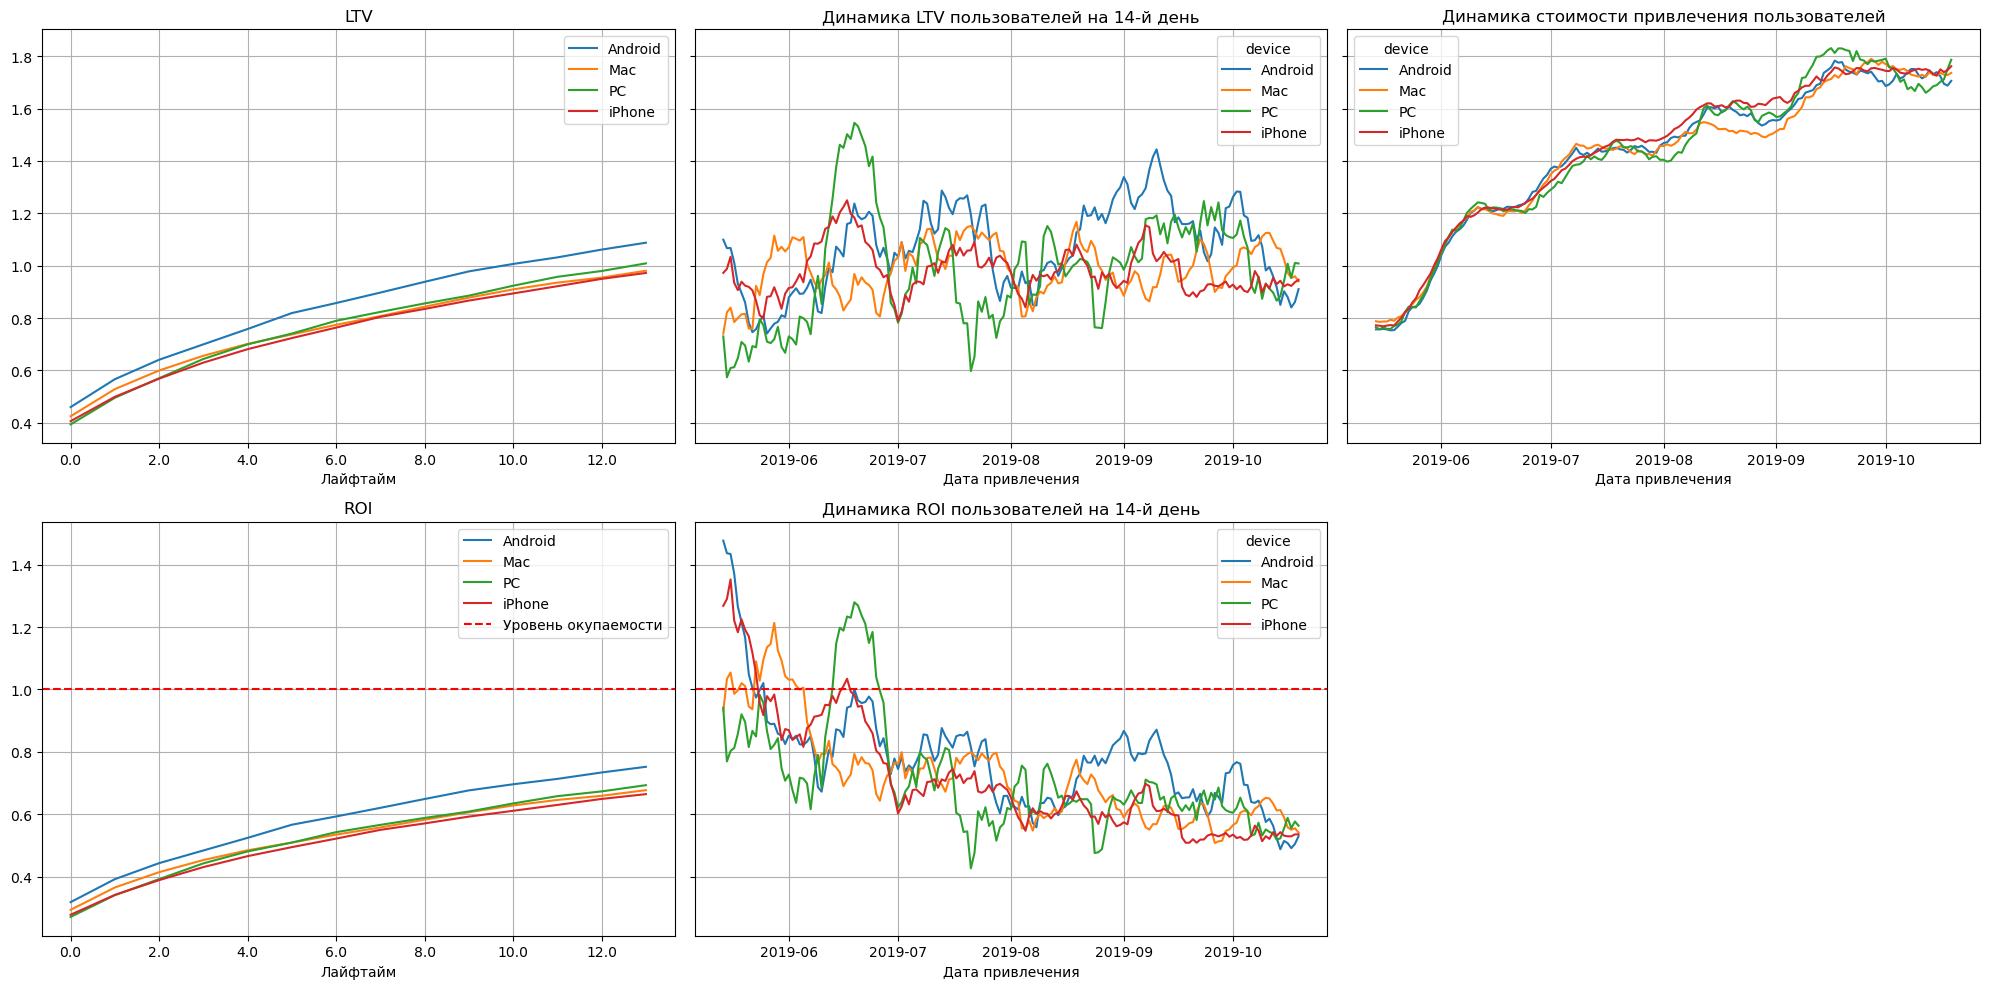

In [47]:
profiles_advertised_US_FB = profiles_advertised_US.query('channel=="FaceBoom"')
dimensions = ['device']

ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles_advertised_US, orders_info, observation_date, horizon_days, dimensions=dimensions
)

plot_ltv_roi(
    ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days, window=14
)

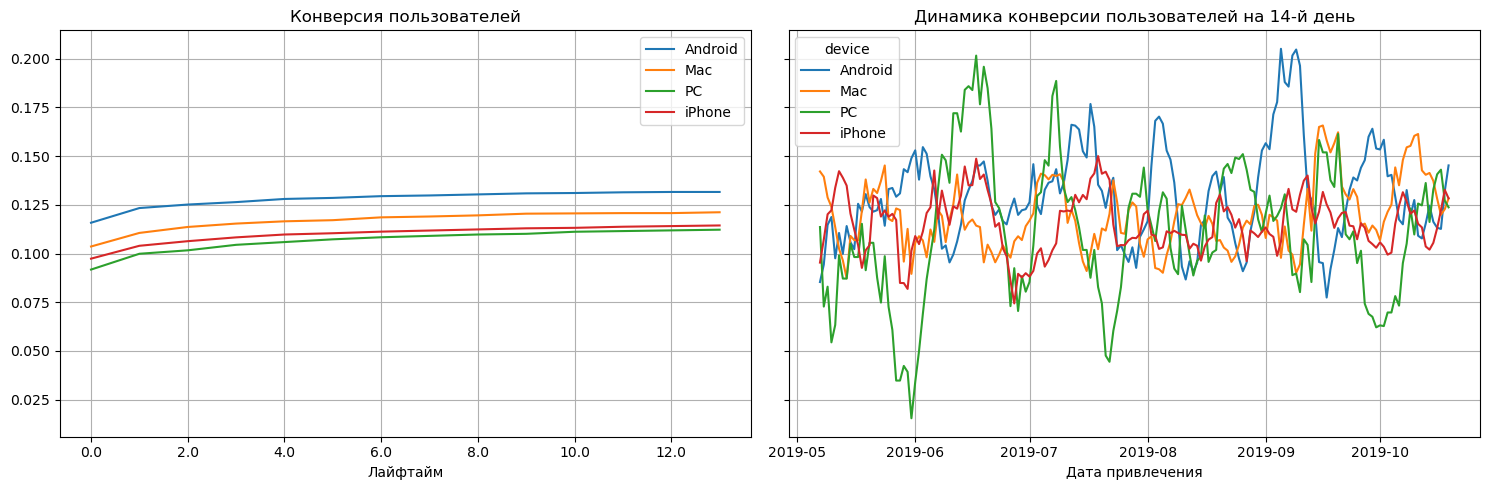

In [48]:
conversion_raw, conversion_grouped, conversion_history = get_conversion(
    profiles_advertised_US_FB, orders_info, observation_date, horizon_days, ['device']
)

plot_conversion(conversion_grouped, conversion_history, horizon_days)

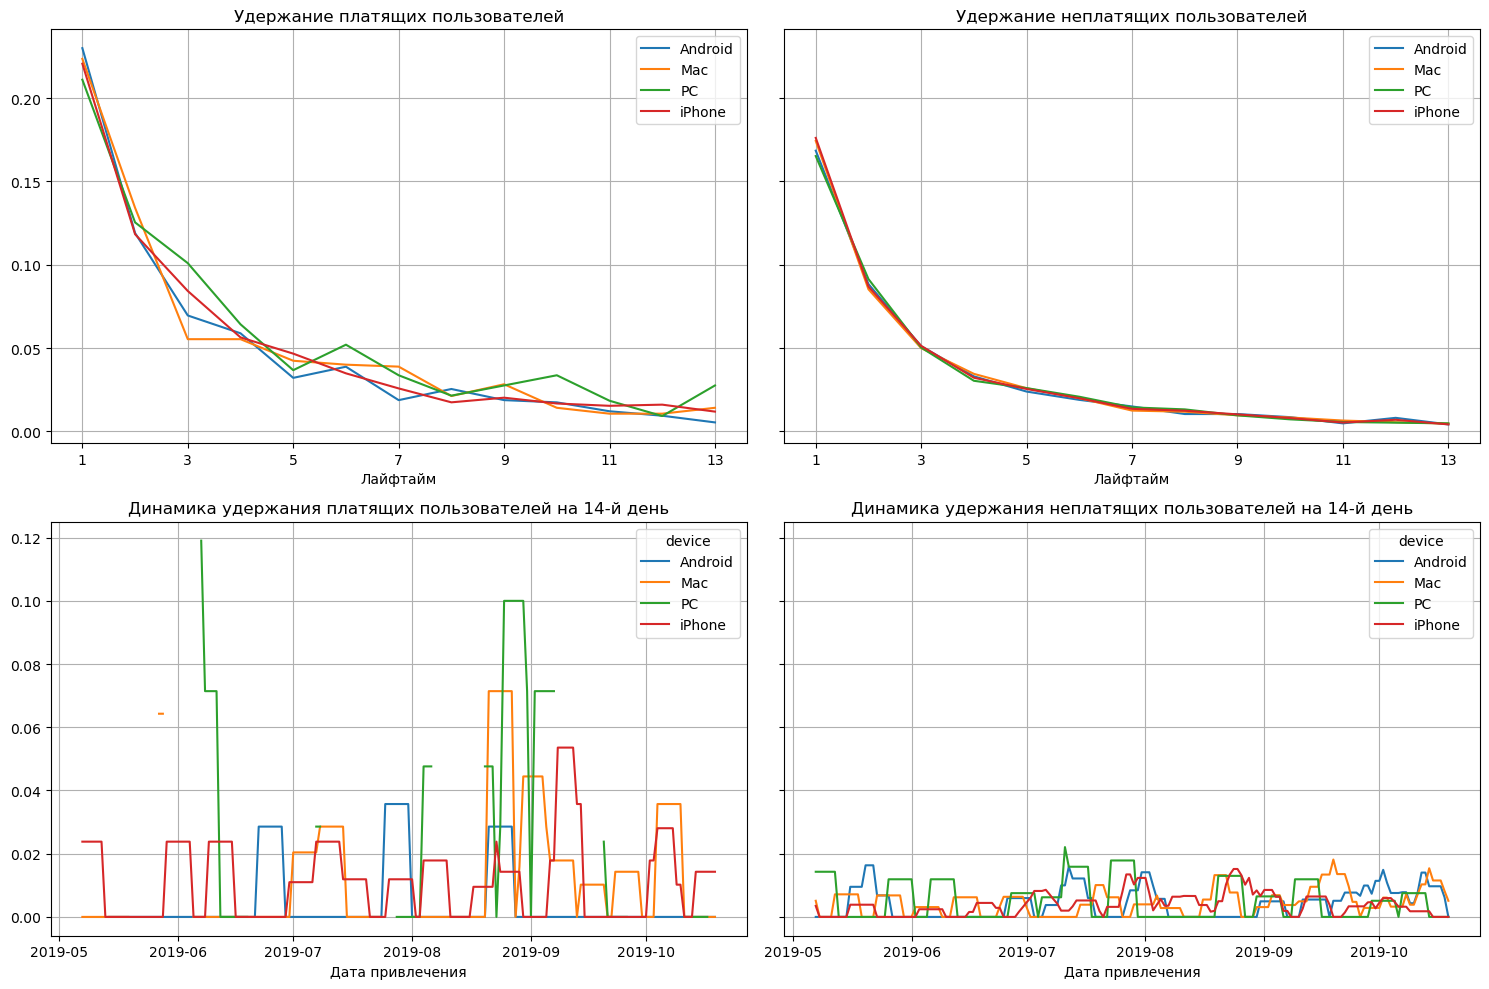

In [49]:
retention_raw, retention_grouped, retention_history = get_retention(
    profiles_advertised_US_FB, visits_info, observation_date, horizon_days, ['device']
)

plot_retention(retention_grouped, retention_history, horizon_days) 

Большой разницы между устройствами не видно.

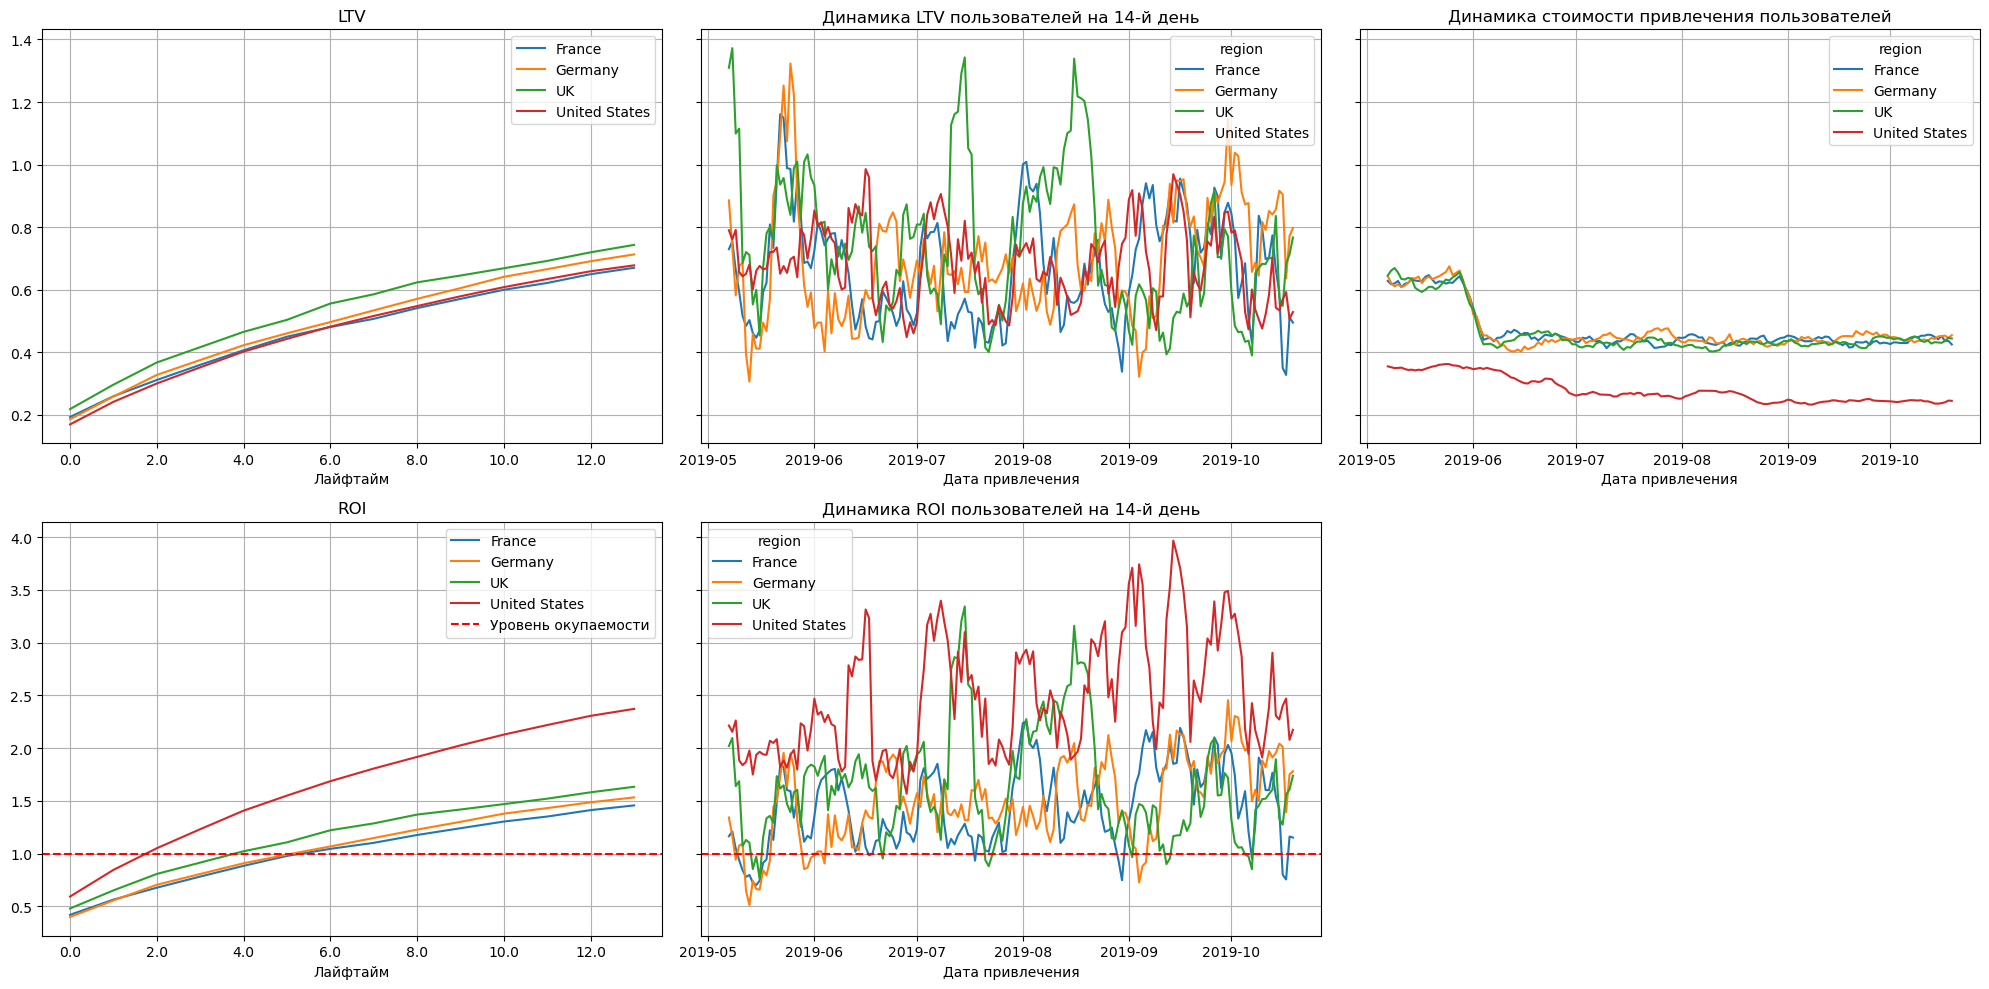

In [50]:
profiles_good_advertised2 = profiles_good_advertised.query('channel!="FaceBoom"')
# считаем LTV и ROI
ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles_good_advertised2, orders_info, observation_date, horizon_days, ['region']
)
# строим графики
plot_ltv_roi(ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days) 

##### Окупаемость рекламы в Европе по каналам

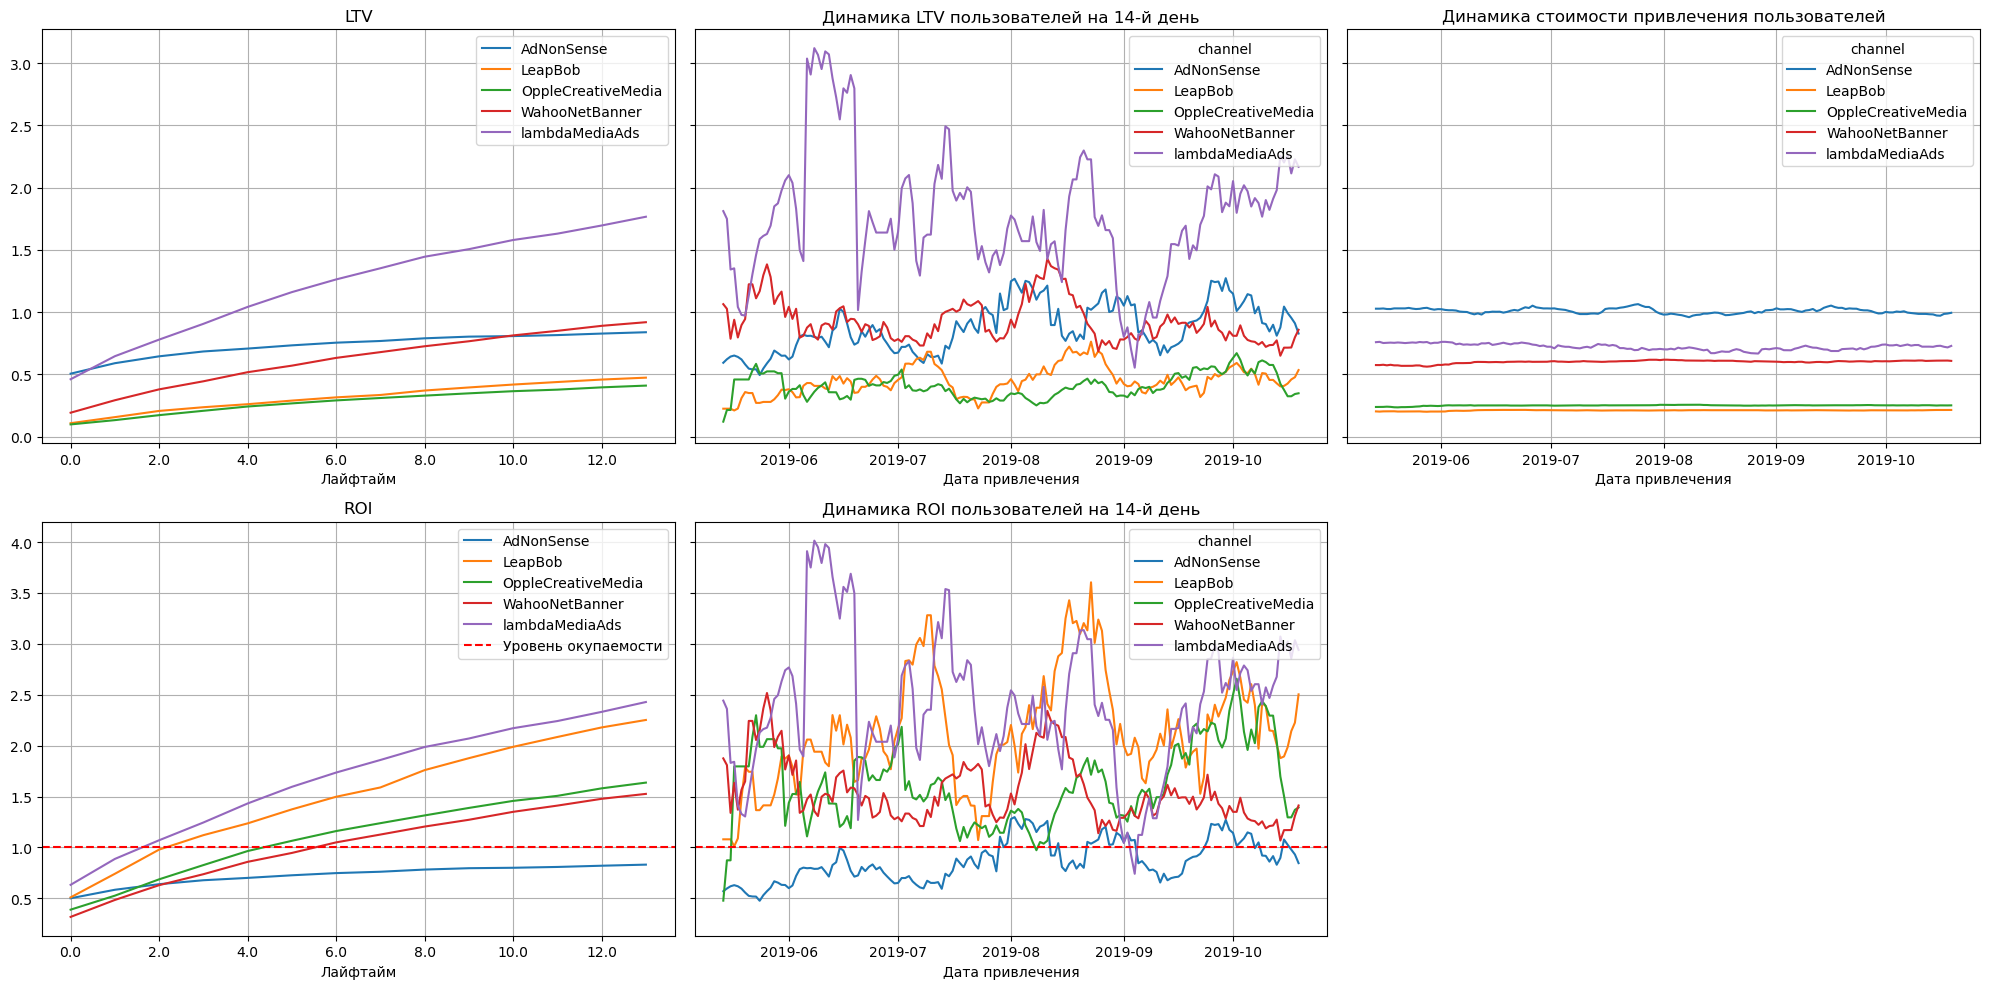

,mean,sum,count
channel,,,
OppleCreativeMedia,0.027077,233,8605
LeapBob,0.030633,262,8553
WahooNetBanner,0.052964,453,8553
AdNonSense,0.113402,440,3880
lambdaMediaAds,0.104700,225,2149


In [51]:
profiles_advertised_EU = profiles_advertised.query('region!="United States"')
dimensions = ['channel']

ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles_advertised_EU, orders_info, observation_date, horizon_days, dimensions=dimensions
)

plot_ltv_roi(
    ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days, window=14
)

profiles_by_channel_EU = pivot_by(profiles_advertised_EU,'channel', {'user_id':['count'], 'payer_count':['mean', 'sum']})
profiles_by_channel_EU = profiles_by_channel_EU.sort_values(by='count',ascending=False)

display(profiles_by_channel_EU)

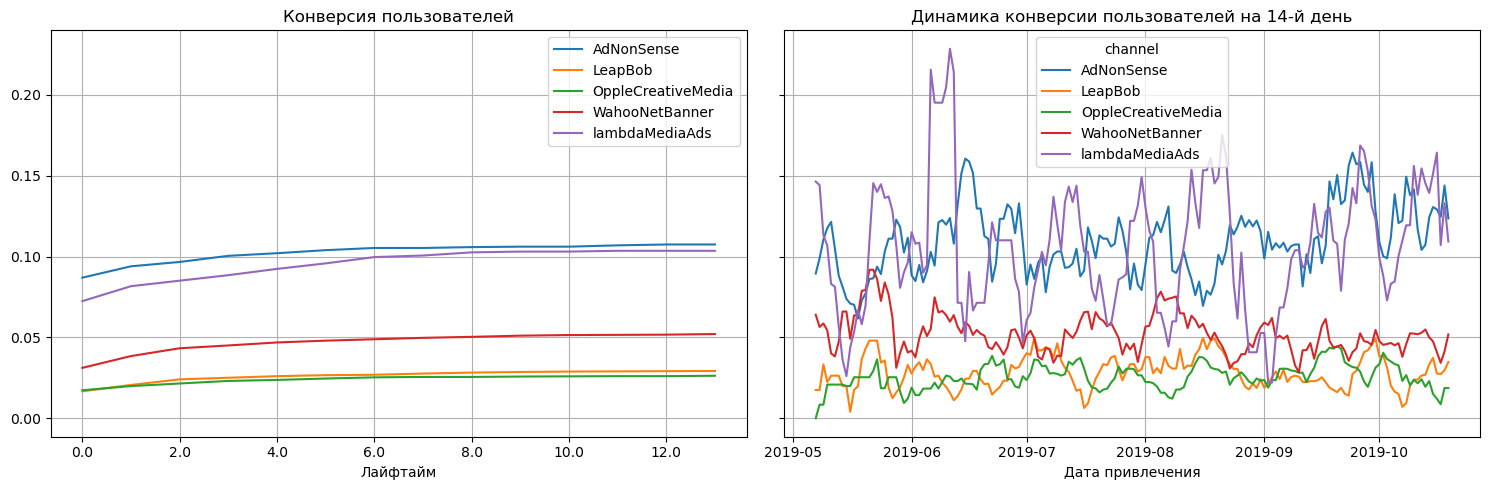

In [52]:
conversion_raw, conversion_grouped, conversion_history = get_conversion(
    profiles_advertised_EU, orders_info, observation_date, horizon_days, ['channel']
)

plot_conversion(conversion_grouped, conversion_history, horizon_days)

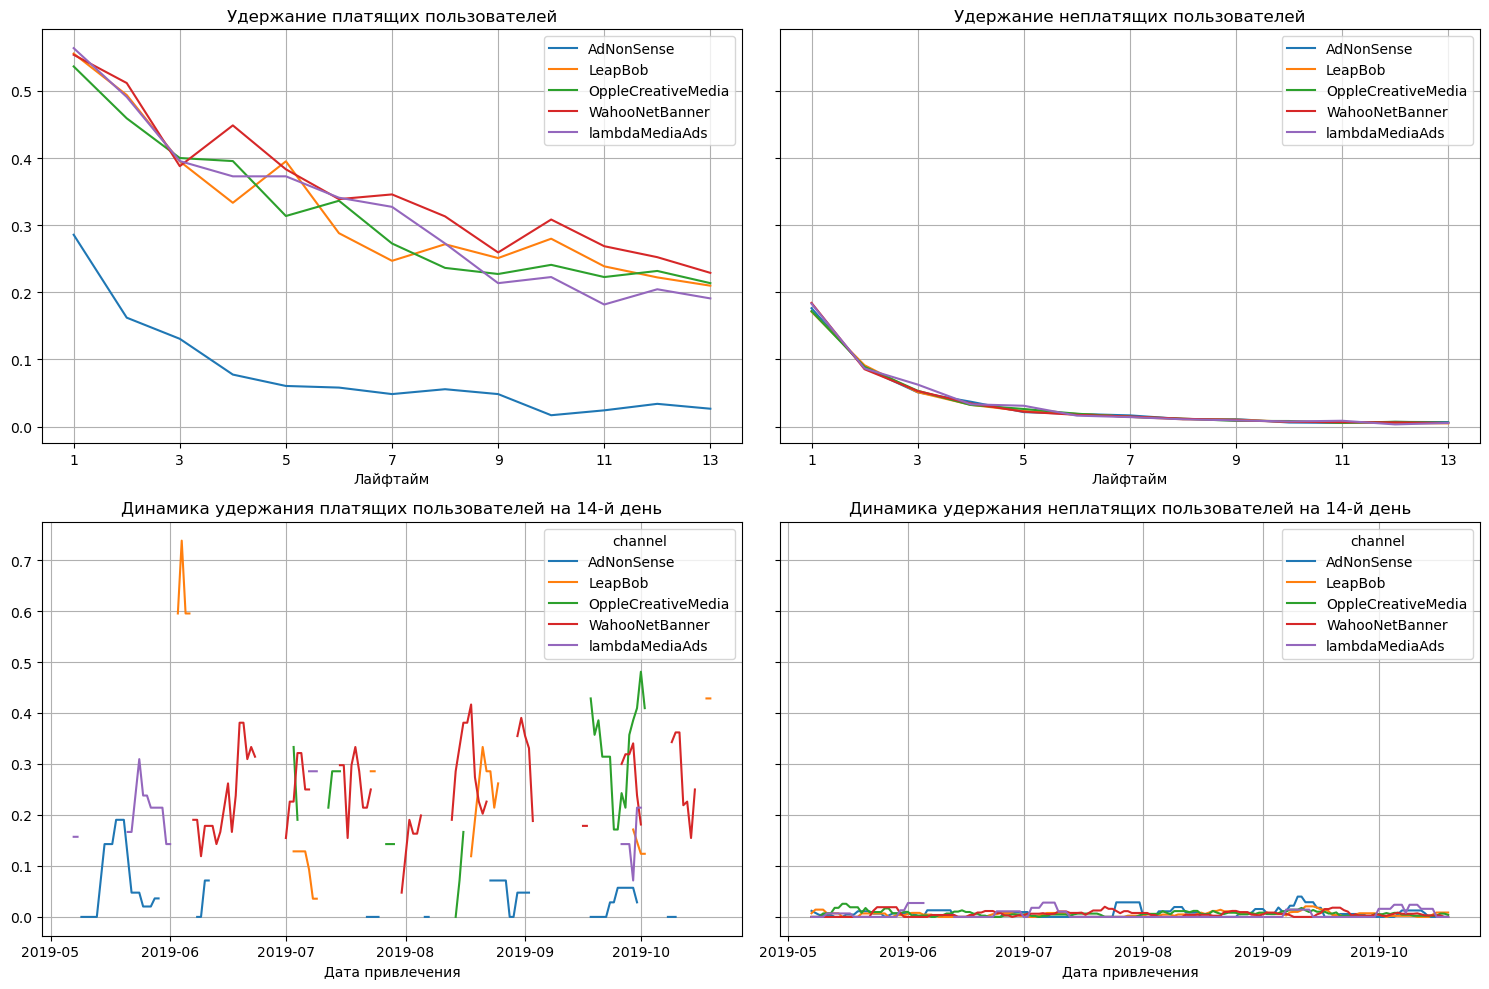

In [53]:
retention_raw, retention_grouped, retention_history = get_retention(
    profiles_advertised_EU, visits_info, observation_date, horizon_days, ['channel']
)

plot_retention(retention_grouped, retention_history, horizon_days) 

Ситуация с AdNonSense в Европе выглядит очень похожей на ситуацию с FaceBoom в Америке - высокая цена привлечения, сравнительно высокая конверсия и чрезвычайно низкое удержание

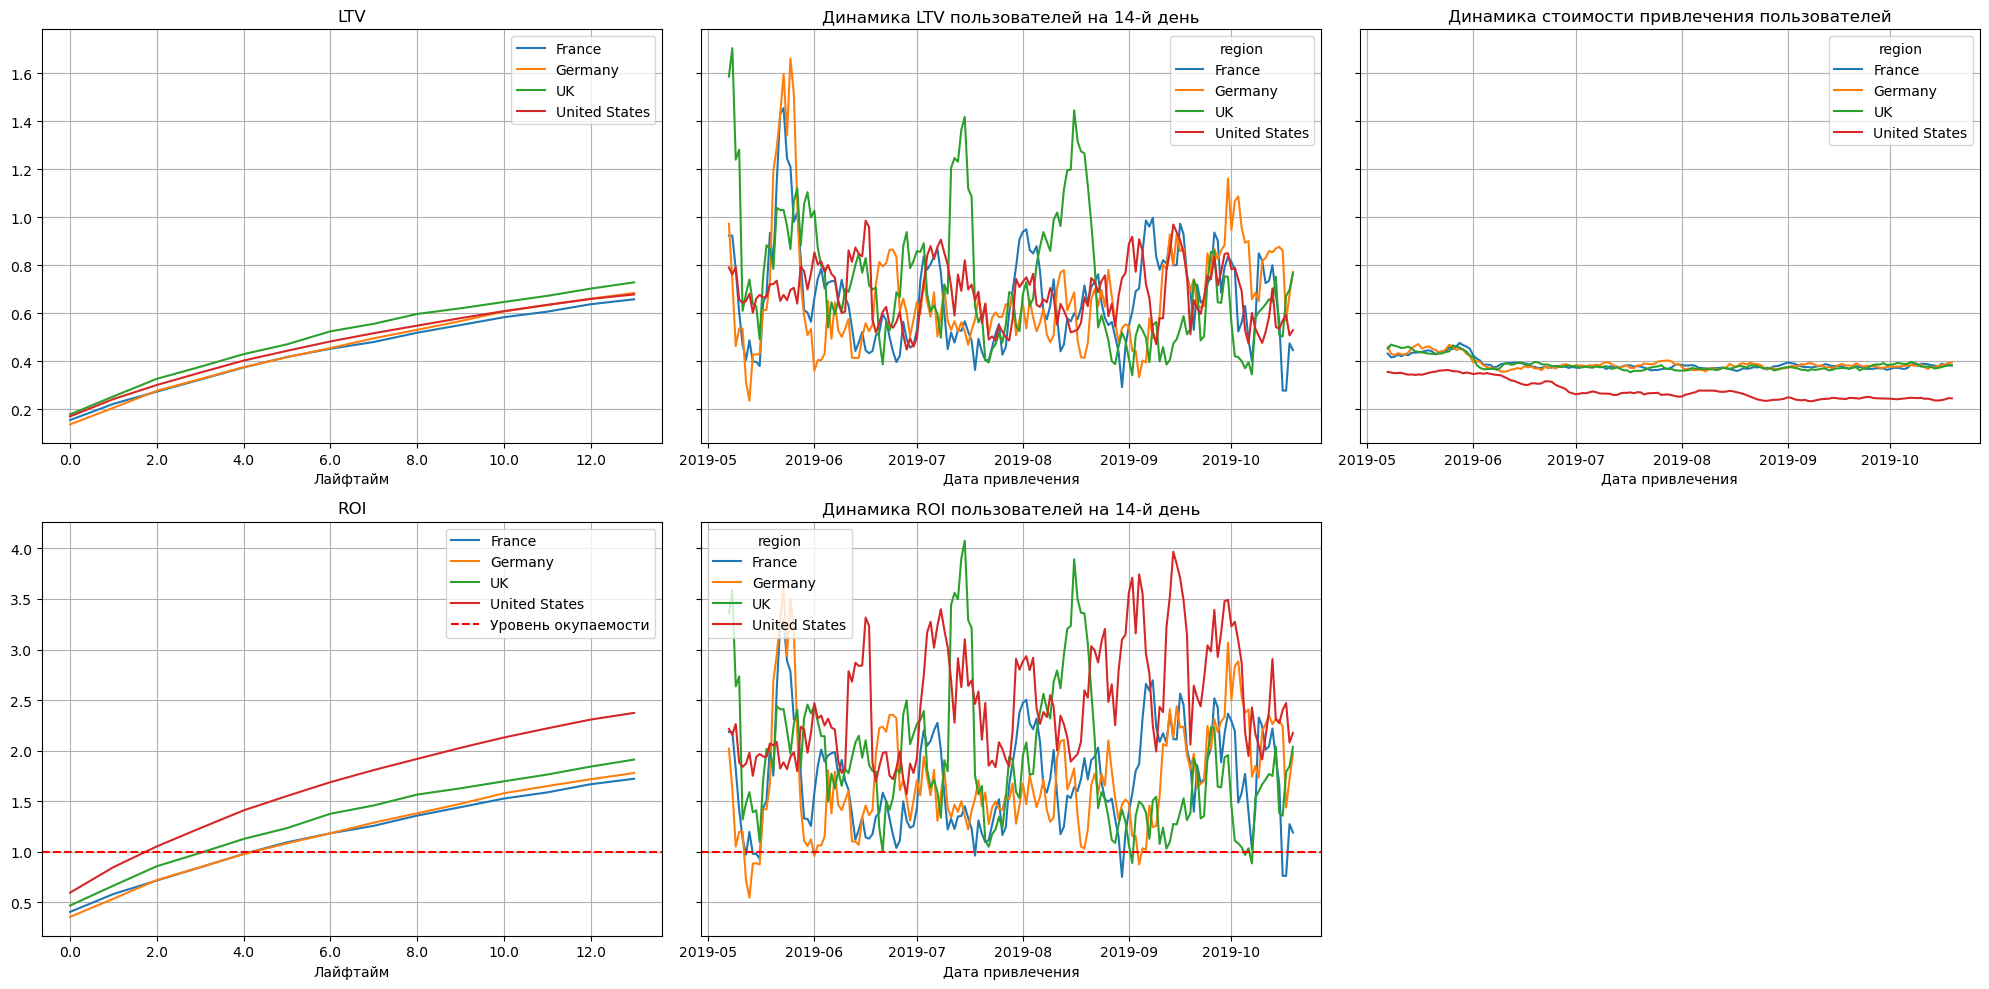

In [54]:
profiles_good_advertised3 = profiles_good_advertised2.query('channel!="AdNonSense"')
# считаем LTV и ROI
ltv_raw, ltv_grouped, ltv_history, roi_grouped, roi_history = get_ltv(
    profiles_good_advertised3, orders_info, observation_date, horizon_days, ['region']
)
# строим графики
plot_ltv_roi(ltv_grouped, ltv_history, roi_grouped, roi_history, horizon_days) 

За вычетом проблемных каналов получается что LTV во всех регионах одинаковое, при этом цена привлечения в США ниже.

### Напишите выводы

- Выделите причины неэффективности привлечения пользователей.
- Сформулируйте рекомендации для отдела маркетинга.

#### Общие данные
Изучены данные о привлечении пользователей представлены за период с 1 мая по 27 октября 2019 года.

Всего за указанный период было привлечено около 150 тысяч пользователей: 100 тысяч из США, по 17 тысяч из Великобритании и Франции, и 15 тысяч из Германии. 
Среди них 55 тысяч пользователей iPhone, 35 тысяч пользователей Android и по 30 тысяч Mac и PC.
Почти 40% пользователей приходят без рекламных компаний, остальные через рекламу. Наиболее крупные каналы привлечения: FaceBoom c 30 тысячами и TipTop c 20 тысячами, также примерно по 8.5 тысяч привлечены через OppleCreativeMedia, LeapBob и WahooNetBanner, остальные источники находятся в диапазоне от 2 до 4.5 тысяч.

Суммарные расходы на рекламу составили ~ 105 тысяч.

Больше всего потратили на рекламу через Tip Top ~ 55 тысяч, при этом это самый дорогой источник привлечения одного пользователя CAC ~ 2.8 доллара на человека.

На втором по потраченной сумме, при этом на первом по количеству привлеченных пользователей FaceBoom, с суммарными затратами ~ 33 тысячи и CAC 1.1.

#### Анализ окупаемости рекламы
В целом расходы на рекламу не окупаются в целевой двухнедельный срок.

Проанализирована окупаемость по типам устройств, рекламным каналам и странам
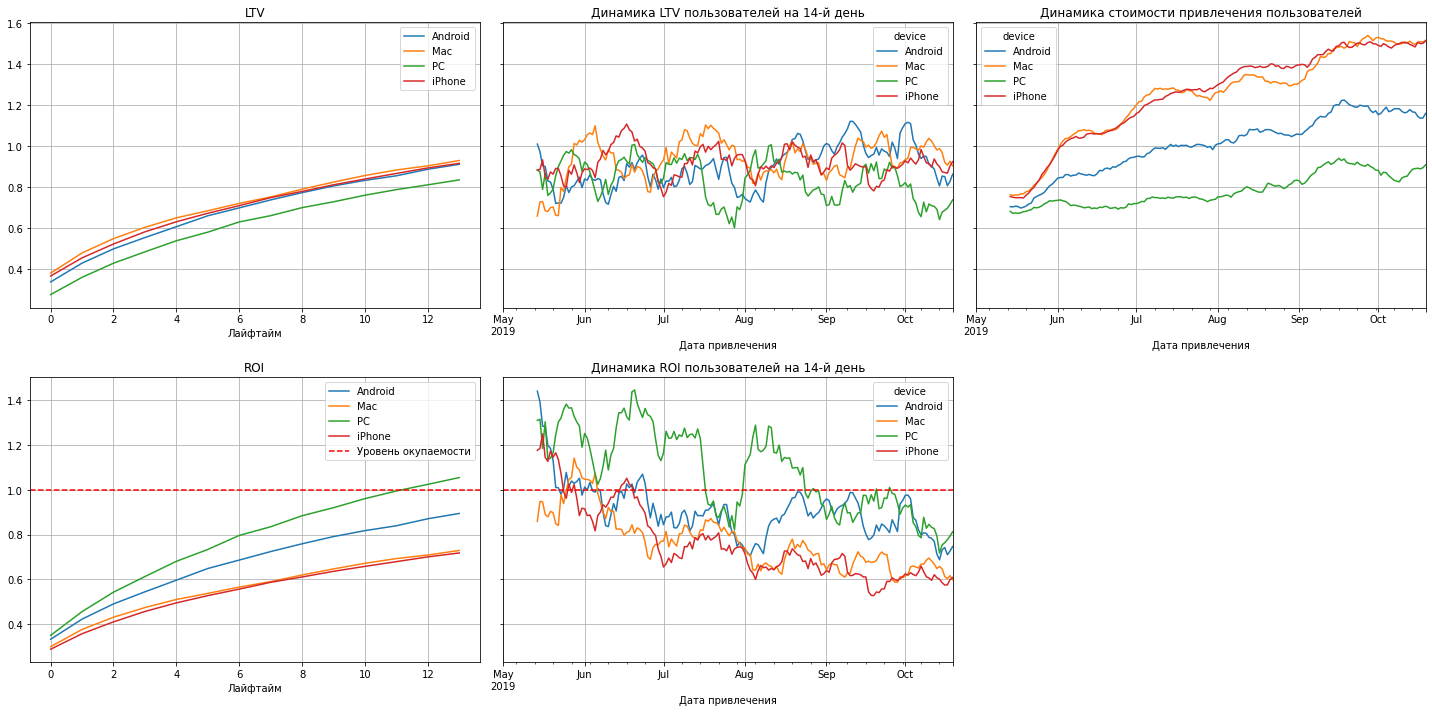
Тип устройства влияет слабо.
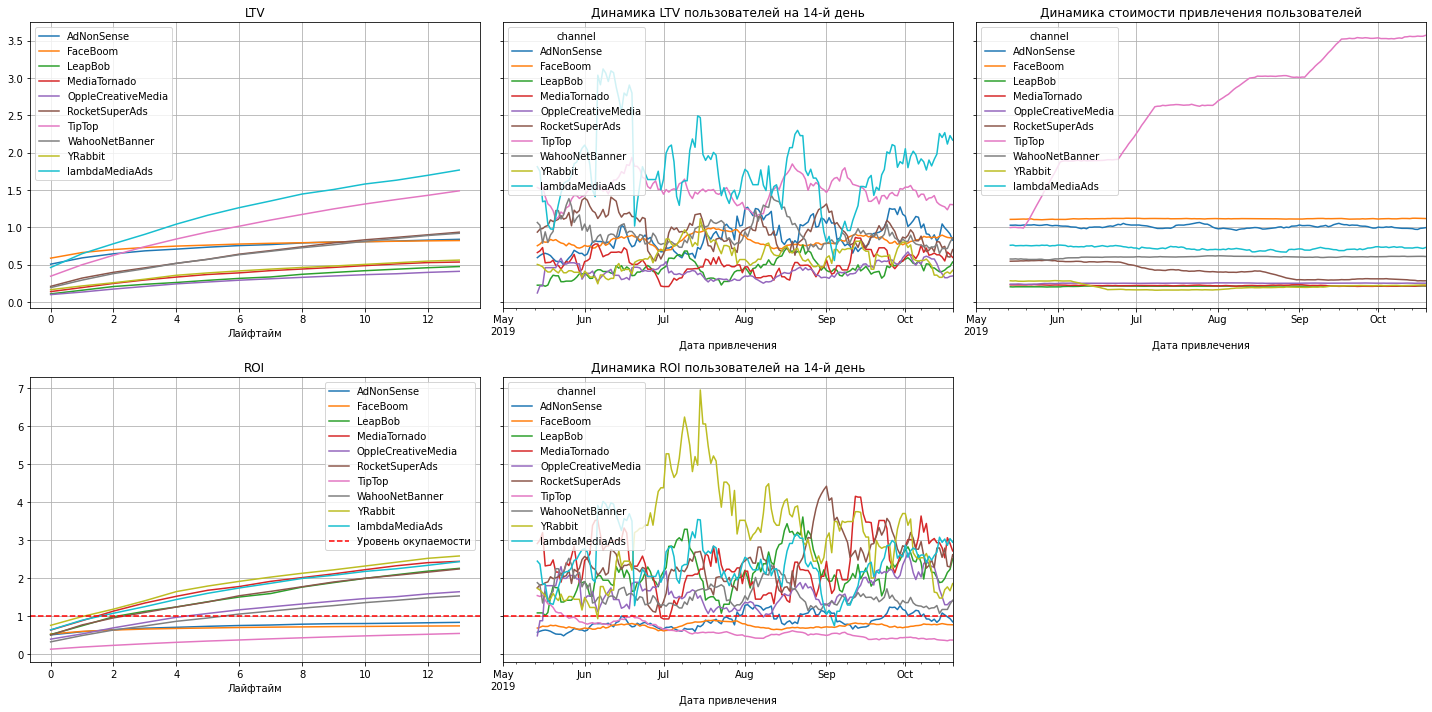
Реклама в двух крупнейших каналах, TipTop и FaceBoom, не окупается, при этом в рамках периода виден резкий рост удельных расходов на рекламу в TipTop.
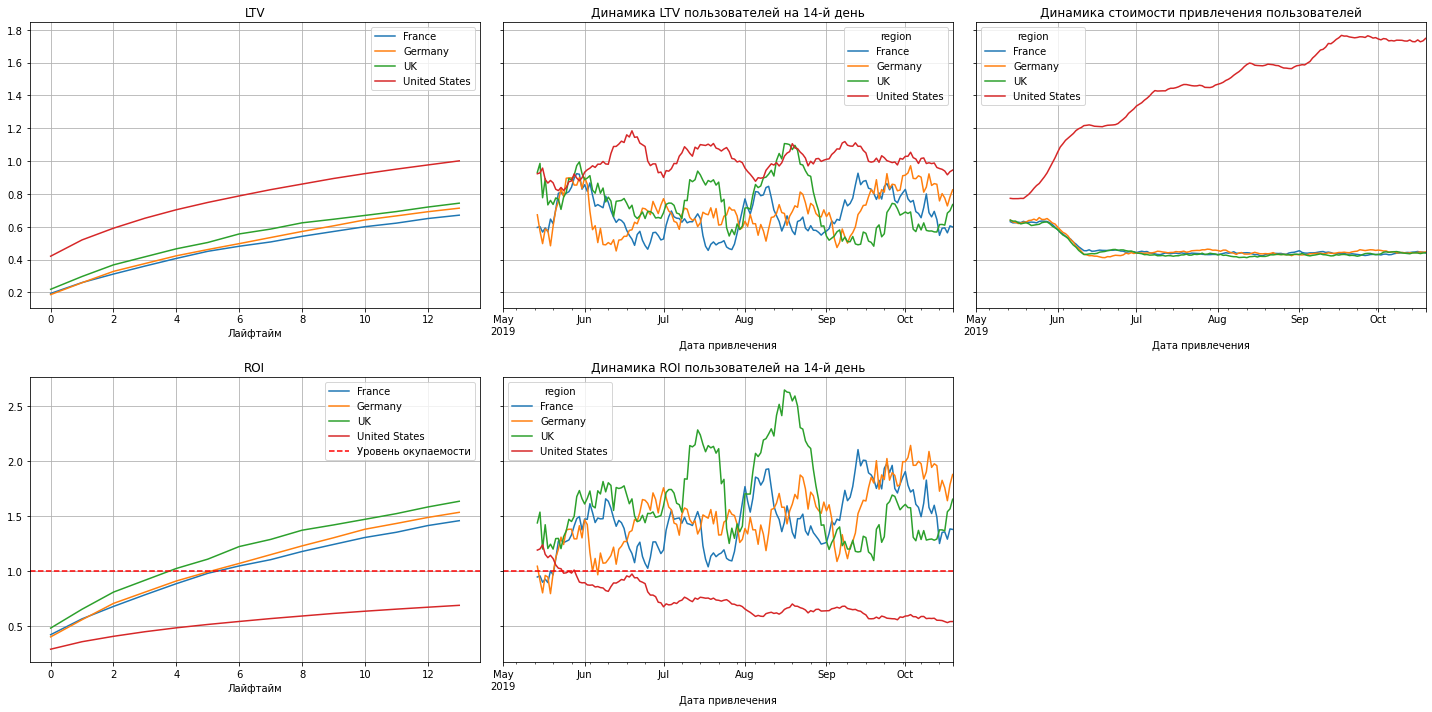
Европейские страны неотличимы друг от друга и реклама в них окупается, реклама в США не окупается.

Так как наиболее подозрительным каналом распространения выглядел TipTop - построены графики без него.
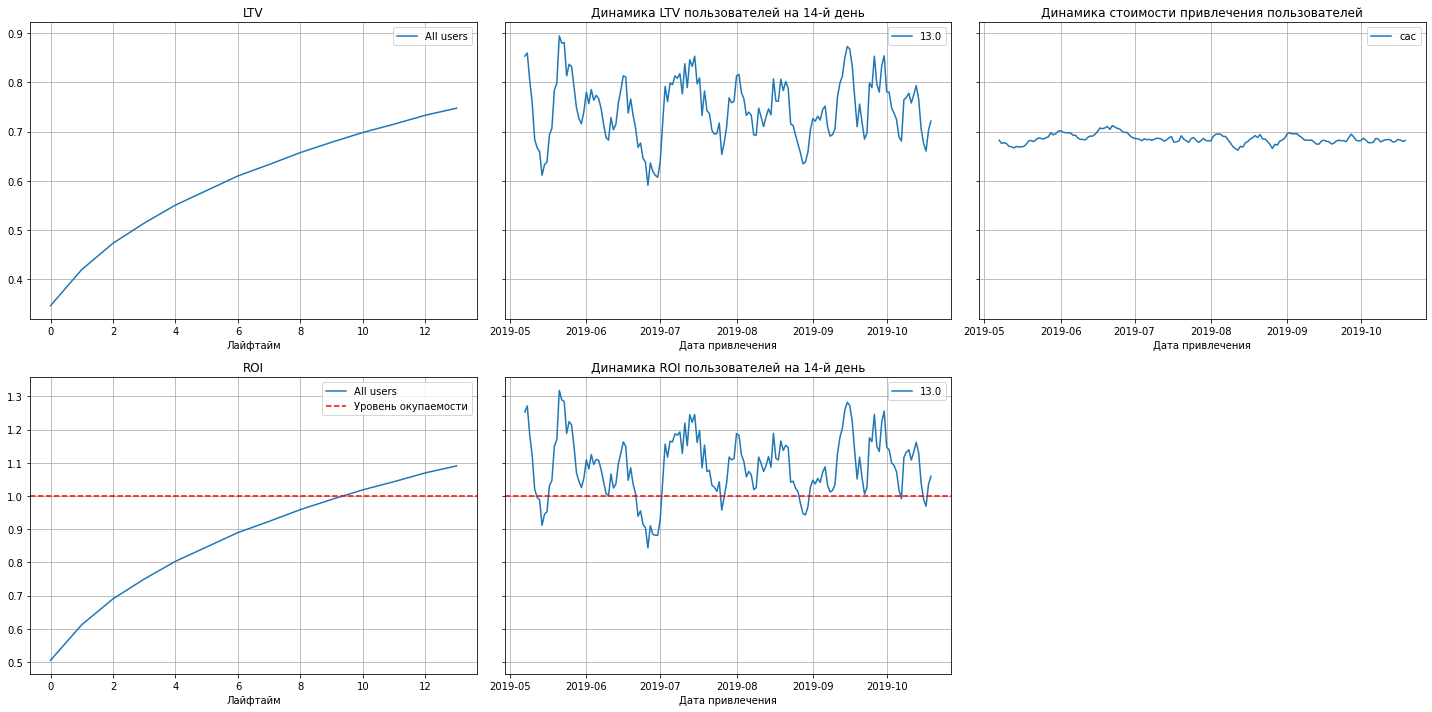
В целом, этого исключения уже достаточно для того, чтобы LTV превысил CAC.

Ситуация на американском рынке:
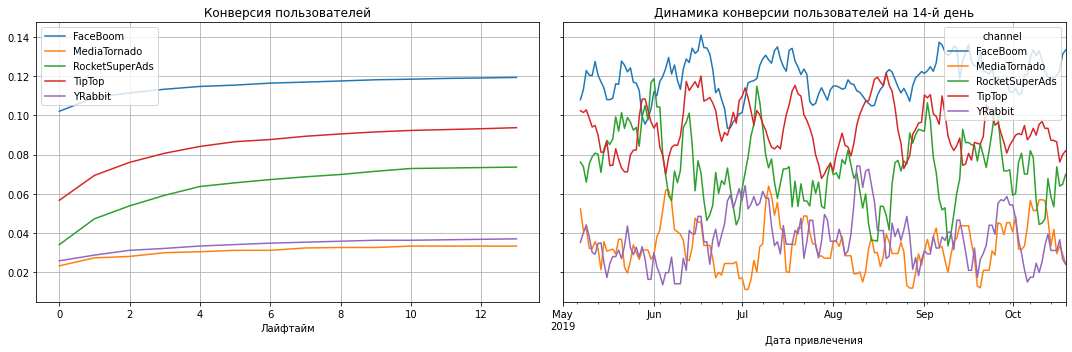
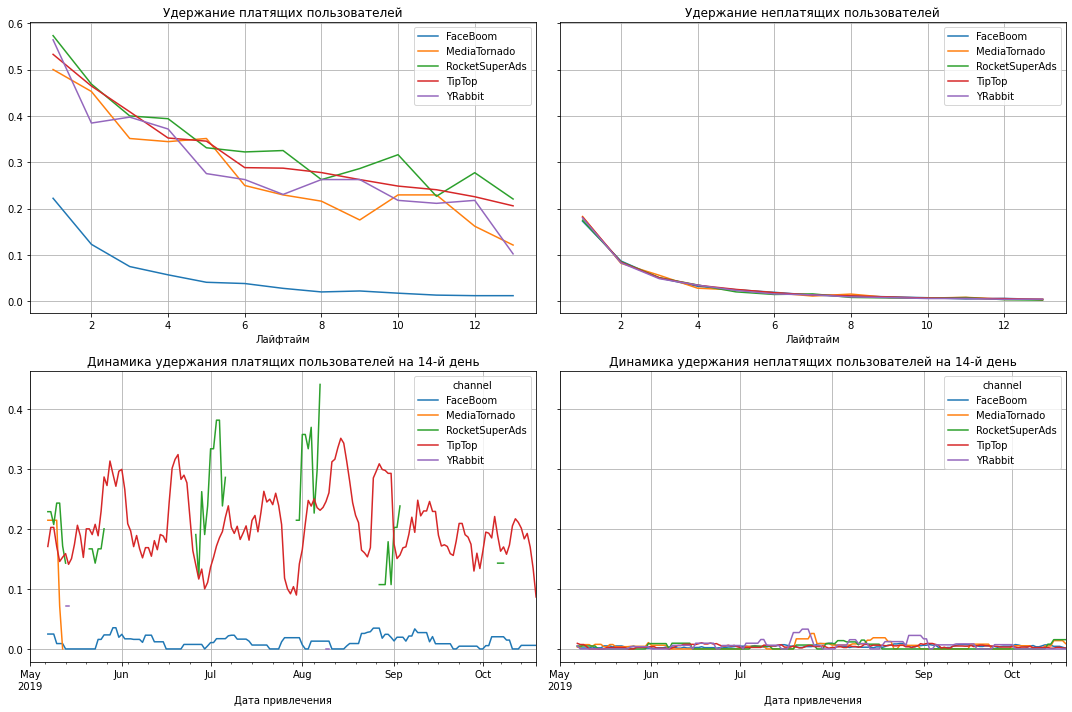
Видно что проблемы каналов различны:
- в TipTop пользователи не выбиваются из общих трендов, но стоимость привлечения более чем вдвое превосходит другие каналы.
- в FaceBoom конверсия даже выше средней, но удержание резко выделяется в худшую сторону.

#### Выводы


- В США использовались два канала, с которыми существенные проблемы, если убрать их из рассмотрения - ситуация в США даже лучше чем в Европе:
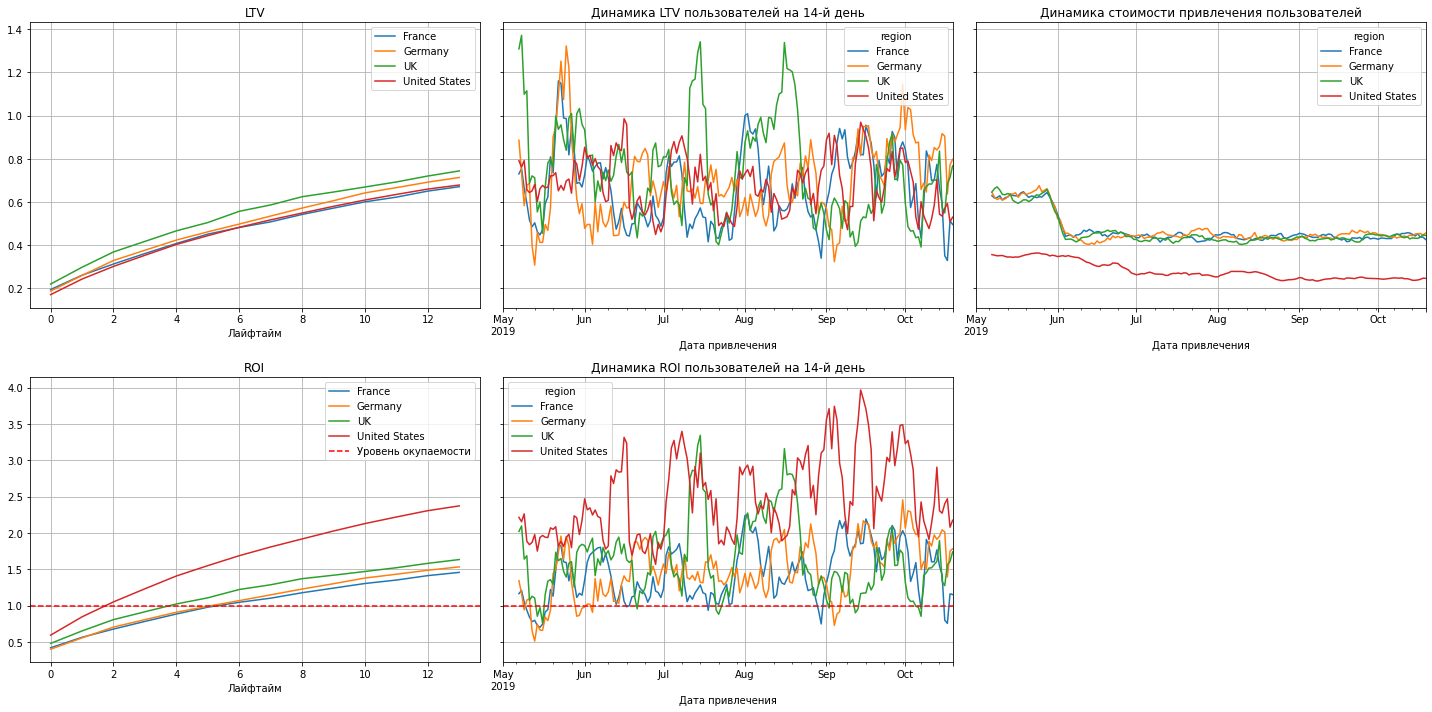

- Расходы на привлечение пользователей через TipTop резко выросли в течение рассматриваемого периода, вероятно их следует сократить или даже полностью отказаться от данного канала:
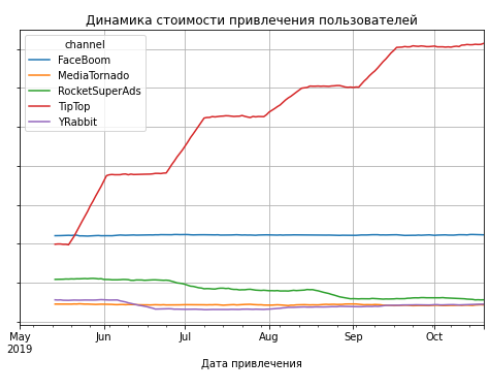

- У пользователей, привлеченных через FaceBoom большие проблемы с удержанием, но для того чтобы определить их причины нужно больше данных. Как один из вариантов можно предположить слабую релевантность рекламных объявлений реальному наполнению приложения
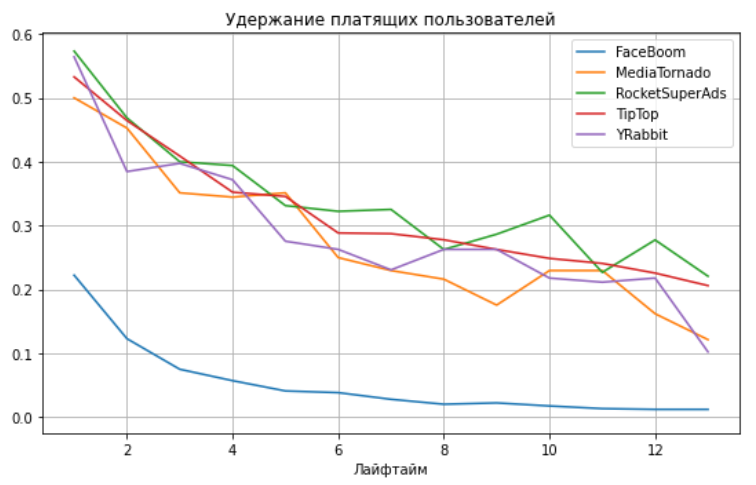

- С AdNonSense в Европе те же проблемы что и с FaceBoom в США:
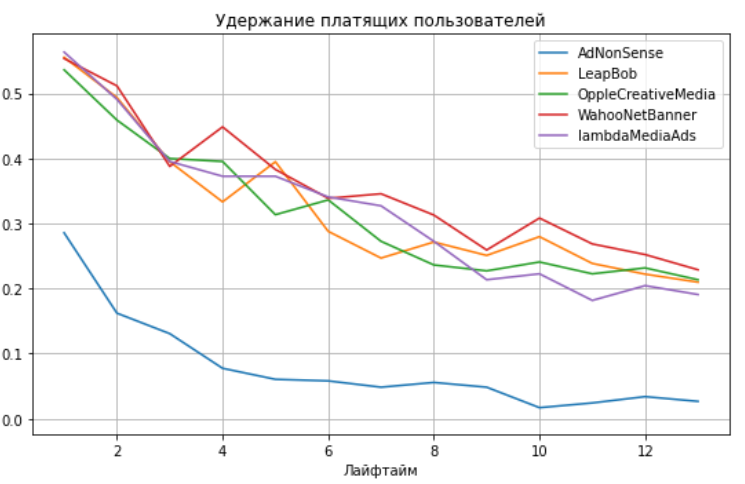

#### Рекомендации

- Отказаться от использования TipTop

- Выяснить причины низкого удержания пользователей пришедших с FaceBoom и AdNonSense, если это невозможно - отказаться от данных каналов

- По американскому рынку: несмотря на двухкратное преимущество в конверсии у RocketSuperAds перед MediaTornado и YRabbit, за счёт более высокой цены привлечения итоговые ROI этих каналов весьма близки. Можно посоветовать распределять бюджет равномерно между всеми тремя.

- По европейскому рынку: lambdaMediaAds и LeapBob имеют ROI более 2, в то время как WahooNetBanner и OppleCreativeMedia около 1.5. Можно порекомендовать сместить расходы в сторону lambdaMediaAds.